# Quantum resource estimates at up to 100 qubits in seconds: linear systems, ODEs, eigenvalues and optimization

No state-vector simulator can hold 100 qubits, whose amplitudes alone occupy $2\times10^{31}$ bytes. This notebook plans five quantum algorithms at that size in seconds, builds and simulates no circuit for them, and labels every count as exact, an upper bound, an estimate or unavailable.

Install with `python -m pip install "nwqlib[aer,notebook]"`. To work on NWQLib itself, run `python -m pip install -e ".[aer,notebook]"` in a clone of the repository instead. Planned circuits reach 109 logical qubits and compiled checks 25, and the notebook runs in about 22 s on an Apple M3 Max with 36 GiB of memory (Python 3.12.14, Qiskit 2.5.2, Aer 0.17.2).

> **How to read this notebook.** The overview and "Before committing" come first, and the explanation starts at Section 1.
>
> - Overview and Before committing: one QLS call at 100 qubits, the result card with its cost, the labels, compiled checks of the gate-count formulas, each plan's quantum and classical cost, and a construction-limit refusal
> - Sections 1 to 5 and the summary: tune a linear solve, budget heat-flow errors, compare two Hamiltonians, price the QHD encodings and a GCiM trial basis
> - Appendices A to F: formulas with independent checks, evidence labels, the capacity assessment, limits at this scale, the full compiled comparison, and cells for your own problem

In [1]:
import numpy as np

from nwqlib import LinearSystem, estimate, plan
from nwqlib.algorithms import QLS
from nwqlib.operators import PeriodicStencil
from nwqlib.problems import ingest_product
from nwqlib.resources import ResourceContext

q = 100                                                # system qubits: a ring of 2**100 sites
my_A = PeriodicStencil(q, mass=1.0, diffusion=0.25)    # A = I + (2I - S - S†)/4, where S shifts the ring by one site
my_b = ingest_product([[np.cos(0.3 + 0.1 * j), np.sin(0.3 + 0.1 * j)] for j in range(q)])  # one factor per qubit

selected = plan(LinearSystem(A=my_A, b=my_b), method=QLS(epsilon_inv=0.01), seed=7)  # selects the construction, runs nothing
resources = estimate(selected, context=ResourceContext(basis="cx"))                  # adds up resource formulas, builds no circuit
print(f"polynomial degree {selected.reconstruction.degree}, "
      f"{resources.quantity('cx').fact.value.value:,.0f} CX gates per attempt (an estimate)")

polynomial degree 11, 225,734 CX gates per attempt (an estimate)


In [2]:
# Display helpers for tables, figures and the result card. Nothing in this cell calls NWQLib.
from html import escape
import sys
from time import perf_counter

import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
SECONDS = {}  # wall-clock seconds of each planning or estimation call on this computer, keyed by a label


def timed(label, call, *args, **kwargs):
    """Return ``call(*args, **kwargs)`` and record its wall-clock seconds under ``label``."""
    start = perf_counter()
    value = call(*args, **kwargs)
    SECONDS[label] = perf_counter() - start
    return value


def pauli_label(q, sites, axis):
    """The q-qubit Pauli label with ``axis`` on ``sites``. Qubit 0 is the rightmost character, as in Qiskit."""
    letters = ["I"] * q
    for site in sites:
        letters[q - 1 - site] = axis
    return "".join(letters)


def number(quantity):
    """A resource quantity of an estimate as a number: an exact integer for rational counts, the float otherwise."""
    value = quantity.fact.value
    if value is None:
        return None
    return value.numerator if value.kind == "rational" and value.denominator == 1 else float(value.value)


def logical_qubits(folded):
    """Logical qubits of one circuit, from an estimate."""
    return number(folded.quantity("logical_width", location="logical_device"))


def peak_memory():
    """Peak resident memory of this Python process in bytes, or None where the platform does not report it."""
    try:
        import resource
    except ImportError:  # Windows has no resource module
        return None
    peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return peak if sys.platform == "darwin" else 1024 * peak  # macOS reports bytes, Linux kibibytes


def format_value(value, digits=3):
    """Round only the display to ``digits`` significant digits. Calculations keep full precision."""
    if value is None:
        return "unavailable"
    if isinstance(value, (int, np.integer)) and not isinstance(value, bool):
        return f"{value:,}"
    if isinstance(value, (float, np.floating)) and value.is_integer() and abs(value) < 1e15:
        return f"{int(value):,}"  # a count that an estimate returns as a float
    if isinstance(value, (float, np.floating)):
        return f"{value:.{digits}g}"
    return str(value)


def table_html(rows, headers=("Quantity", "Value", "Meaning and scope"), *, digits=3):
    """Rows of computed values as an HTML table."""
    heading = "".join("<th>" + escape(label) + "</th>" for label in headers)
    body = "".join("<tr>" + "".join('<td style="text-align:left">' + escape(format_value(value, digits)) + "</td>"
                                    for value in row) + "</tr>" for row in rows)
    return "<table><thead><tr>" + heading + "</tr></thead><tbody>" + body + "</tbody></table>"


def show_table(rows, headers=("Quantity", "Value", "Meaning and scope"), *, digits=3, details=None):
    """Display rows of computed values, optionally collapsed under a summary line."""
    table = table_html(rows, headers, digits=digits)
    if details is not None:
        table = "<details><summary>" + escape(details) + "</summary>" + table + "</details>"
    display(HTML(table))


def figure_html(fig, description):
    """The figure as an inline PNG image, so that it can sit inside a collapsed block."""
    from base64 import b64encode
    from io import BytesIO

    buffer = BytesIO()
    fig.savefig(buffer, format="png")
    plt.close(fig)
    return (f'<img alt="{escape(description)}" src="data:image/png;base64,'
            + b64encode(buffer.getvalue()).decode("ascii") + '">')


LABELS = {"estimate": "Estimate", "upper_bound": "Upper bound", "exact": "Exact count"}


def show_accuracy_summary(checks, seconds, per_construction=2):
    """Show the two largest compiled sizes of each construction and a sentence computed from all the checks."""
    names = list(dict.fromkeys(row["construction"] for row in checks))
    shown = [row for name in names for row in [row for row in checks if row["construction"] == name][-per_construction:]]
    agree = sum(row["law"] == row["compiled"] for row in checks)

    def words(items):
        items = [str(item) for item in items]
        return items[0] if len(items) == 1 else ", ".join(items[:-1]) + " and " + items[-1]

    groups = {}  # constructions that were compiled at the same sizes
    for name in names:
        short = name.replace("Periodic ", "").replace("QCELS, ", "").replace(" chain", " QCELS")
        groups.setdefault(tuple(row["q"] for row in checks if row["construction"] == name), []).append(short)
    spread = " and ".join(f"{words(group)} at {words(sizes)}" for sizes, group in groups.items())
    display(HTML(
        table_html([(row["construction"], row["q"], row["law"], LABELS[row["interpretation"]], row["compiled"],
                     "equal" if row["law"] == row["compiled"] else f"ratio {row['law'] / row['compiled']:.3g}")
                    for row in shown],
                   headers=("Construction", "System qubits", "CX from the formula", "Label", "Compiled CX, level 0",
                            "Agreement"))
        + f"<p>The formula's CX count equals the compiled count in {'all' if agree == len(checks) else agree} of "
        f"{len(checks)} checks, for {spread} system qubits. They took {seconds:.0f} s here. The 80–100-qubit counts "
        "rest on the same formulas and are not compiled. Appendix E has every comparison and its compiler "
        "settings.</p>"))


def show_card(sizes, qls, qls_cx, lchs, lchs_cx, qpe, qpe_fold, qpe_cx, gcim_cx, peak):
    """Show the result card: the key numbers, the QLS and LCHS figure and what NWQLib did, then, collapsed, the
    QPE and GCiM results, the timing and the state-vector memory."""
    top = sizes[-1]
    cx = {"QLS": [number(qls_cx[q].quantity("cx")) for q in sizes],
          "LCHS": [number(lchs_cx[q].quantity("cx")) for q in sizes],
          "GCiM": [number(gcim_cx[q].quantity("cx")) for q in sizes]}
    steps = {model: [qpe[model, q].reconstruction.powers[-1].steps for q in sizes] for model in ("Ising", "Heisenberg")}
    norm = qpe["Ising", top].reconstruction.spectral_radius_bound
    lchs_steps = lchs[top].reconstruction.step_counts[0]
    budget = qpe["Ising", top].method.controlled_power_error_budget
    display(HTML(
        f"<p><strong>Result.</strong> At {top} system qubits, this configuration estimates {cx['QLS'][-1] / 1e3:.3g} "
        f"thousand CX gates for one QLS attempt and bounds one LCHS attempt by {cx['LCHS'][-1] / 1e6:.3g} million CX "
        f"gates.</p>"
        f"<p><strong>Cost at {top} system qubits.</strong> Quantum, logical and predicted: QLS {logical_qubits(qls_cx[top])} qubits "
        f"and {format_value(cx['QLS'][-1])} CX per attempt (an estimate), LCHS {logical_qubits(lchs_cx[top])} qubits and at most {format_value(cx['LCHS'][-1])} CX per "
        f"attempt, and QPE on the Ising chain {logical_qubits(qpe_fold['Ising', top])} qubits, "
        f"{number(qpe_fold['Ising', top].quantity('shots')):,} shots and {number(qpe_cx['Ising', top].quantity('cx')):,} CX "
        f"over all shots. Classical, measured on this computer: the {len(SECONDS)} planning and estimation calls took "
        f"{sum(SECONDS.values()):.1f} s together, and this Python process, imported libraries included, had peaked at "
        f"{format_value(None if peak is None else peak / 2**20)} MiB of memory by then.</p>"))

    def plot_cx(ax, family, color, marker, style, title, label, scale, unit, ylabel):
        ax.plot(sizes, cx[family], marker=marker, linestyle=style, color=color)
        ax.set_ylim(0, 1.2 * max(cx[family]))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _, scale=scale, unit=unit: f"{value / scale:g}{unit}"))
        ax.set_title(title, loc="left")
        ax.set_ylabel(ylabel)
        ax.text(0.04, 0.80, label, transform=ax.transAxes, color=color)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), layout="constrained")
    plot_cx(axes[0], "QLS", "#0072B2", "o", "-", "QLS: screened Poisson", "Estimate", 1e3, "k",
            "CX gates per coherent attempt")
    plot_cx(axes[1], "LCHS", "#D55E00", "s", "--", "LCHS: heat flow", "Upper bound", 1e6, "M",
            "CX gates per coherent attempt")
    axes[0].text(0.04, 0.93, rf"$\kappa={qls[top].reconstruction.kappa_be:g},\ \epsilon_{{\rm inv}}={qls[top].method.epsilon_inv:g}$",
                 transform=axes[0].transAxes, va="top")
    axes[1].text(0.04, 0.93, f"{lchs_steps} steps, ideal error bounds sum to < 0.01", transform=axes[1].transAxes, va="top")
    for ax in axes:
        ax.set(xlabel="System qubits q", xticks=sizes)
        ax.grid(axis="y", alpha=0.2)
    plt.show()
    display(HTML(
        "<p>CX gates of one coherent attempt, the QLS count as the library's estimate and the LCHS count as an upper "
        "bound, from the resource formulas without building a circuit. Lines join the three planned sizes to guide the eye "
        "and are not fits.</p>"))
    done = (
        "Read each problem in compact form, a periodic stencil with a product or basis state, or a list of Pauli terms, "
        "and formed no vector or matrix with 2<sup>q</sup> entries.",
        f"Selected each construction and its accuracy controls, namely an inverse polynomial of degree "
        f"{qls[top].reconstruction.degree} for QLS, {lchs[top].reconstruction.physical_branches} LCHS branches whose "
        f"cutoff and quadrature meet their error share and {lchs_steps} Strang steps for the product-formula share, "
        f"a product-formula step count for each QPE power on its own, whose complete bound is at most {budget:g}, and "
        f"the {number(gcim_cx[top].quantity('settings'))} measurement settings that the GCiM trial basis needs.",
        "Added up the resource formulas of each selected construction for qubits, logical operations, CX gates, "
        "measurement settings and shots, and recorded whether each total is exact, an upper bound, an estimate or "
        "unavailable.",
    )
    display(HTML("<p><strong>What NWQLib did for you.</strong></p><ol>"
                 + "".join(f"<li>{step}</li>" for step in done) + "</ol>"))

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), layout="constrained")
    for model, color, marker, style in (("Ising", "#0072B2", "o", "-"), ("Heisenberg", "#009E73", "s", "--")):
        axes[0].plot(sizes, steps[model], marker=marker, linestyle=style, color=color, label=model)
    axes[0].text(0.04, 0.93, rf"$T_{{\max}}={qpe['Ising', top].reconstruction.powers[-1].evolution_time:g},\ "
                 rf"\epsilon_U={budget:g}$", transform=axes[0].transAxes, va="top")
    axes[0].text(0.04, 0.80, "Exact count from a proved bound*", transform=axes[0].transAxes)
    axes[0].set_title("QPE: commutator structure", loc="left")
    axes[0].set(ylabel="Steps at the longest time", ylim=(0, 1.3 * max(steps["Heisenberg"])))
    axes[0].legend(loc="lower right", frameon=False)
    plot_cx(axes[1], "GCiM", "#CC79A7", "D", "--", "GCiM: parity Hamiltonian", "Upper bound", 1e6, "M",
            "CX gates over all shots")
    axes[1].text(0.04, 0.93, f"2 trial states, {number(gcim_cx[top].quantity('settings'))} settings",
                 transform=axes[1].transAxes, va="top")
    for ax in axes:
        ax.set(xlabel="System qubits q", xticks=sizes)
        ax.grid(axis="y", alpha=0.2)
    others = (
        f"<p>QPE planning selects {steps['Ising'][-1]} and {steps['Heisenberg'][-1]} product-formula steps at the "
        f"longest evolution time for two spin chains with the same coefficient 1-norm {norm:g}. Over "
        f"{number(qpe_fold['Ising', top].quantity('shots')):,} shots each, the two QPE workloads need "
        f"{number(qpe_cx['Ising', top].quantity('cx')) / 1e9:.3g} and "
        f"{number(qpe_cx['Heisenberg', top].quantity('cx')) / 1e9:.3g} billion CX gates. A fixed GCiM trial basis of two "
        f"product states for a parity Hamiltonian needs {number(gcim_cx[top].quantity('settings'))} measurement "
        f"settings, {number(gcim_cx[top].quantity('shots')):,} shots and at most {cx['GCiM'][-1] / 1e6:.3g} million CX "
        f"gates.</p>"
        + figure_html(fig, "QPE step counts and GCiM CX bound against the system qubits")
        + "<p>Left: the product-formula steps that QPE selects for its longest evolution time, the smallest count whose "
        f"ideal bound fits the allowance {budget:g}, with a complete recorded bound at most {budget:g}. Right: an upper bound on the CX gates of the whole GCiM workload, "
        "every setting at all its shots. *QPE uses an upward-rounded commutator coefficient, checked against an "
        "independent exact commutator count within the derived window in Appendix A. Each recorded bound is the exact sum of the "
        "product-formula, represented-time and parameter-formation terms, rounded upward.</p>")
    widths = {q: [number(estimate_q.quantity("logical_width", location="logical_device"))
                  for estimate_q in (qls_cx[q], lchs_cx[q], qpe_fold["Ising", q], gcim_cx[q])] for q in sizes}
    memory = (
        "<p><strong>State-vector memory.</strong> A complex128 state vector stores 16 bytes for each of its "
        "2<sup>n</sup> amplitudes, so on n qubits it occupies 2<sup>n+4</sup> bytes. At these sizes the system register "
        "alone needs the bytes below, and the selected circuits add their ancillas. This is the requirement of an "
        "unpartitioned state vector. It is not a lower bound on every classical algorithm or compressed simulation "
        "method.</p>"
        + table_html([(q, float(16 * 2**q), " / ".join(str(width) for width in widths[q])) for q in sizes],
                     headers=("System qubits q", "State vector of the system alone, bytes",
                              "Total qubits n of QLS / LCHS / QPE / GCiM")))
    display(HTML("<details><summary>QPE and GCiM, timing and state-vector memory</summary>" + others + memory
                 + "</details>"))

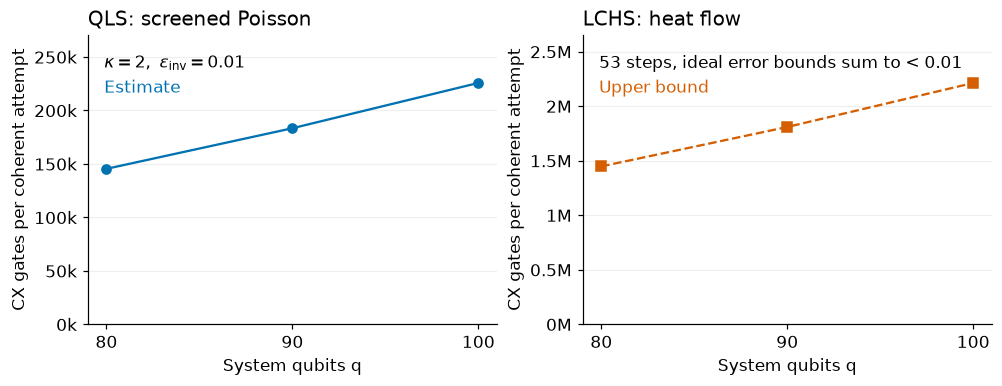

System qubits q,"State vector of the system alone, bytes",Total qubits n of QLS / LCHS / QPE / GCiM
80,1.93e+25,84 / 89 / 81 / 81
90,1.98e+28,94 / 99 / 91 / 91
100,2.03e+31,104 / 109 / 101 / 101

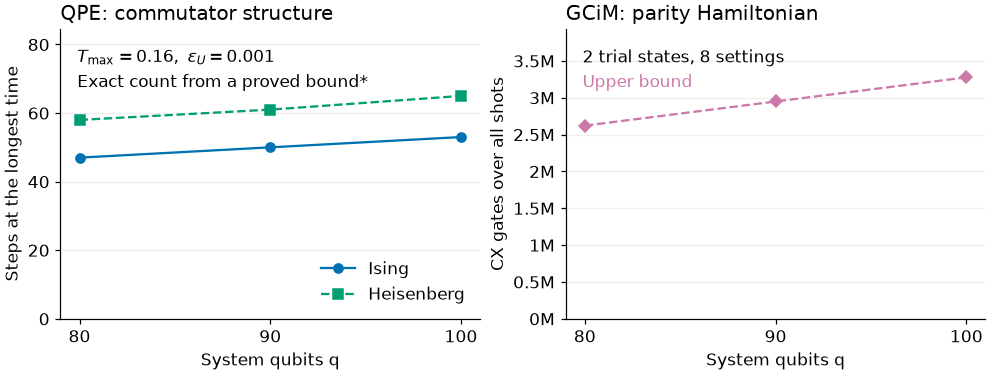

In [3]:
from nwqlib import Eigenproblem, LinearDynamics, NormSquared
from nwqlib.algorithms import LCHS
from nwqlib.algorithms.gcim import FixedGCIM
from nwqlib.algorithms.qpe import QCELS
from nwqlib.operators import ingest_pauli
from nwqlib.problems import ingest_occupation

SIZES = (80, 90, 100)                                 # system qubits q
QLS_TOLERANCE = 0.01                                  # Section 1
SELECTION_ALLOWANCE, STRANG_ALLOWANCE = 0.005, 0.005  # Section 2
POWER_ALLOWANCE, SHOTS = 0.001, 1024                  # Section 3
QCELS_SCHEDULE = dict(tau=0.005, max_time=0.16, num_times=32, grid_size=256)
CX, SERIAL = ResourceContext(basis="cx"), ResourceContext(batch_schedule="serial")
SERIAL_CX = ResourceContext(basis="cx", batch_schedule="serial")


def screened_poisson(q):
    """Section 1: A = I + (2I - S - S†)/4 on a ring of 2**q sites, and a product-state right-hand side."""
    b = ingest_product([[np.cos(0.3 + 0.1 * j), np.sin(0.3 + 0.1 * j)] for j in range(q)])
    return LinearSystem(A=PeriodicStencil(q, mass=1.0, diffusion=0.25), b=b)


def chain_terms(q, model):
    """Section 3: the periodic Ising or Heisenberg chain on q spins as Pauli terms, in product-formula order."""
    bonds = [(j, (j + 1) % q) for j in range(q)]
    if model == "Ising":  # (3/2) Σ_j (Z_j Z_{j+1} + X_j)
        return [term for j, k in bonds for term in ((pauli_label(q, (j, k), "Z"), 1.5), (pauli_label(q, (j,), "X"), 1.5))]
    return [(pauli_label(q, (j, k), axis), 1.0) for j, k in bonds for axis in "XYZ"]  # Σ_j (X_jX_{j+1} + Y_jY_{j+1} + Z_jZ_{j+1})


# Section 1: QLS selects the inverse polynomial, and estimate adds up the CX formulas of its construction.
qls = {q: timed(("QLS plan", q), plan, screened_poisson(q), method=QLS(epsilon_inv=QLS_TOLERANCE), seed=7) for q in SIZES}
qls_cx = {q: timed(("QLS CX", q), estimate, qls[q], context=CX) for q in SIZES}

# Section 2: du/dt = -(2I - S - S†)u/4 until time 1 from a unit point source. LCHS sizes its kernel cutoff and
# quadrature for SELECTION_ALLOWANCE, then takes the smallest Strang step count that meets STRANG_ALLOWANCE.
heat_flow = {q: LinearDynamics(A=PeriodicStencil(q, mass=0.0, diffusion=0.25),
                               initial_state=ingest_occupation("0" * q, num_qubits=q), time=1.0) for q in SIZES}
lchs_method = LCHS(hamiltonian_evolution_backend="trotter", approximation_tolerance=SELECTION_ALLOWANCE,
                   trotter_steps=None, trotter_synthesis_tolerance=STRANG_ALLOWANCE)
lchs = {q: timed(("LCHS plan", q), plan, heat_flow[q], method=lchs_method, output=NormSquared(), seed=7) for q in SIZES}
lchs_cx = {q: timed(("LCHS CX", q), estimate, lchs[q], context=CX) for q in SIZES}
steps = lchs[100].reconstruction.step_counts[0]

# Section 3: QCELS on |0101...⟩ selects the product-formula steps of every power from the Hamiltonian's commutators.
neel_qcels = {q: QCELS(initial_state=ingest_occupation("01" * (q // 2), num_qubits=q),
                       controlled_power_error_budget=POWER_ALLOWANCE, **QCELS_SCHEDULE) for q in SIZES}
qpe = {(model, q): timed((model, "plan", q), plan, Eigenproblem(A=ingest_pauli(chain_terms(q, model), num_qubits=q)),
                         method=neel_qcels[q], shots=SHOTS, seed=7)
       for model in ("Ising", "Heisenberg") for q in SIZES}
qpe_fold = {key: timed((key[0], "estimate", key[1]), estimate, qpe[key], context=SERIAL) for key in qpe}
qpe_cx = {key: timed((key[0], "CX", key[1]), estimate, qpe[key], context=SERIAL_CX) for key in qpe}

# Section 5: GCiM projects A = -Z^⊗q - 0.7 X^⊗q onto two product trial states, measured in qubit-wise-commuting groups.
parity = {q: Eigenproblem(A=ingest_pauli([("Z" * q, -1.0), ("X" * q, -0.7)], num_qubits=q)) for q in SIZES}
trial_basis = {q: FixedGCIM(basis=tuple(ingest_product([[np.cos(theta), np.sin(theta)]] * q)
                                        for theta in (np.pi / 8, 3 * np.pi / 8))) for q in SIZES}
gcim = {q: timed(("GCiM plan", q), plan, parity[q], method=trial_basis[q], shots=SHOTS, seed=7) for q in SIZES}
gcim_cx = {q: timed(("GCiM CX", q), estimate, gcim[q], context=SERIAL_CX) for q in SIZES}

planning_peak = peak_memory()  # bytes, after every planning and estimation call above
show_card(SIZES, qls, qls_cx, lchs, lchs_cx, qpe, qpe_fold, qpe_cx, gcim_cx, planning_peak)

**What each label means.** Every resource count and error bound carries one of four labels.

| Label | Meaning | Numbers with this label here |
| --- | --- | --- |
| Exact count | An integer that the selected construction fixes | qubits, encoding queries, LCHS branches, product-formula steps, measurement settings, shots, QPE logical operations and CX gates, one-hot QHD rotations |
| Upper bound | A value that the named count, or the named ideal error component, cannot exceed | LCHS, QHD and GCiM CX gates before optimization and routing, binary QHD rotation slots, and the error bounds |
| Estimate | A library value recorded with `numerical_estimate` or `estimate` evidence, not as a bound | QLS CX gates, the one-hot QHD preparation error |
| Unavailable | No resource formula of the construction covers the quantity, and it is never reported as zero | circuit depth and T gates of the QLS and LCHS plans (Appendix B) |

**Scope.** No circuit is simulated and no noise is modelled. The counts are logical, so physical qubits, error-correction overhead, hardware run time and price are not estimated, and neither are the circuit depth and T gates of the QLS and LCHS plans.

<details><summary>How each bound is evaluated</summary>

The QLS, LCHS and QPE error bounds are analytic formulas. The QLS inverse-polynomial residual and the LCHS kernel-tail and quadrature bounds are evaluated in binary64 arithmetic, without an interval enclosure of every rounding. The LCHS Strang bound is evaluated in exact rational arithmetic from the stored binary64 data and recorded rounded upward. QPE forms an upward bound on its Pauli commutator coefficient using scaled binary64 products and sums, then combines that rational upper coefficient with the stored time and integer step count exactly and rounds the recorded bound upward. Appendix A checks the coefficient against an independent exact rational commutator count within a derived relative window. QHD evaluates its ideal-evolution bound outward, rounding upward (Section 4). The integer counts and the LCHS CX bound follow exact integer formulas. The QPE CX gates are exact for the decomposition that Qiskit 2.5.2 emits for each controlled Pauli rotation, before optimization and routing. Appendix A rederives the CX counts, the QPE logical operations, the LCHS bounds, the QHD counts and evolution bounds, and the LCHS and QPE step counts independently of NWQLib, and Appendix B lists the record behind every label.

</details>

**The formula behind every number, checked against compiled circuits.** Each count comes from a gate-count formula of the selected construction ([mathematics](../docs/mathematics.md), Appendix A). The next cell builds the same constructions at small sizes, compiles them with Qiskit and compares the compiled CX count with the formula. It simulates nothing.

In [4]:
from nwqlib import prepare
from nwqlib.execution import ExecutionLimits

SMALL_SIZES = (4, 6, 8, 12, 16)  # system qubits of the compiled QLS and LCHS checks, with the accuracy controls above
SMALL_SPINS = (4, 8)             # spins of the compiled QPE checks, with the schedule and allowance above
LEVEL_0 = {"basis_gates": ["cx", "u"], "optimization_level": 0, "seed_transpiler": 7, "approximation_degree": 1.0}
BUILD_ONLY = ExecutionLimits(max_simulation_qubits=32)  # allows building the 25-qubit LCHS circuit, nothing is simulated


def small_plan(family, q):
    """The Section 1, 2 or 3 construction on q system qubits, with the same accuracy controls."""
    if family == "QLS":
        return plan(screened_poisson(q), method=QLS(epsilon_inv=QLS_TOLERANCE), seed=7)
    if family == "LCHS":
        problem_q = LinearDynamics(A=PeriodicStencil(q, mass=0.0, diffusion=0.25),
                                   initial_state=ingest_occupation("0" * q, num_qubits=q), time=1.0)
        return plan(problem_q, method=lchs_method, output=NormSquared(), seed=7)
    return plan(Eigenproblem(A=ingest_pauli(chain_terms(q, family), num_qubits=q)), shots=SHOTS, seed=7,
                method=QCELS(initial_state=ingest_occupation("01" * (q // 2), num_qubits=q),
                             controlled_power_error_budget=POWER_ALLOWANCE, **QCELS_SCHEDULE))


compiled_checks, optimized_cx, started = [], None, perf_counter()
for family in ("QLS", "LCHS"):
    for q in SMALL_SIZES:
        selected_small = small_plan(family, q)
        law = estimate(selected_small, context=CX).quantity("cx")
        prepared = prepare(selected_small, progress=False, limits=BUILD_ONLY)  # builds the circuit, runs nothing
        with prepared.run:                                       # the prepared Run holds the circuit until the block ends
            inventory = prepared.inspect_resources(max_operations=10_000_000, transpile_options=LEVEL_0)
            if family == "QLS" and q == SMALL_SIZES[0]:
                optimized_cx = prepared.inspect_resources(
                    transpile_options={**LEVEL_0, "optimization_level": 3})["operations"].get("cx", 0)
        compiled_checks.append({"construction": f"Periodic {family}", "q": q, "width": inventory["num_qubits"],
                                "plan": selected_small, "interpretation": law.interpretation, "law": number(law),
                                "compiled": inventory["operations"].get("cx", 0)})
for model in ("Ising", "Heisenberg"):
    for q in SMALL_SPINS:
        small_qpe = small_plan(model, q)
        law = estimate(small_qpe, context=SERIAL_CX).quantity("cx")
        prepared = prepare(small_qpe, settings="all", progress=False)  # builds the circuit of every setting, runs nothing
        with prepared.run:
            # Each circuit, in the order of setting_names, weighted by the shots of its setting.
            compiled = sum(prepared.inspect_resources(index=index, transpile_options=LEVEL_0)["operations"].get("cx", 0)
                           * small_qpe.resolve(name).resolved_observation(small_qpe)[1].shots
                           for index, name in enumerate(prepared.setting_names))
            settings, width = len(prepared.setting_names), prepared.inspect_resources(index=0)["num_qubits"]
        compiled_checks.append({"construction": f"QCELS, {model} chain", "q": q, "width": width, "plan": small_qpe,
                                "settings": settings, "interpretation": law.interpretation, "law": number(law),
                                "compiled": compiled})
compile_seconds = perf_counter() - started
show_accuracy_summary(compiled_checks, compile_seconds)

Construction,System qubits,CX from the formula,Label,"Compiled CX, level 0",Agreement
Periodic QLS,12,"4,062",Estimate,"4,062",equal
Periodic QLS,16,"6,746",Estimate,"6,746",equal
Periodic LCHS,12,"114,738",Upper bound,"114,738",equal
Periodic LCHS,16,"138,906",Upper bound,"138,906",equal
"QCELS, Ising chain",4,"15,040,512",Exact count,"15,040,512",equal
"QCELS, Ising chain",8,"41,680,896",Exact count,"41,680,896",equal
"QCELS, Heisenberg chain",4,"38,535,168",Exact count,"38,535,168",equal
"QCELS, Heisenberg chain",8,"103,415,808",Exact count,"103,415,808",equal


The GCiM CX bound is twice the compiled count of its eight circuits on 3 system qubits, $R=2$ (Appendix E). It is an upper bound on the CX gates of the selected controlled product preparations, not an exact count.

**Optimization.** Section 4 prices one step of quantum Hamiltonian descent (QHD) in the one-hot and binary encodings, up to 96 qubits.

**Your own problem.** The first cell accepts a periodic stencil with positive mass and no potential, and a product right-hand side. Appendix F has standalone cells for heat flow and for a Hamiltonian given as Pauli terms, with the input format and size limits of each route.

[Why NWQLib](../docs/why_nwqlib.md) compares this workflow with other packages.

## Before committing

**What does each plan cost, and could a classical machine simulate it instead?** The table lists the quantum and classical cost of the 100-qubit plans. The quantum counts are predicted from the selected constructions, per coherent attempt for QLS and LCHS and over all shots for QPE and GCiM.

Construction work is NWQLib's upper bound on the classical work of building each circuit, in units rather than seconds. The memory and the planning and estimation seconds are measured here.

In [5]:
# The illustrative one-pebibyte allocation that `assess` compares a state vector with. It plans and runs nothing.
from datetime import datetime, timedelta, timezone

from nwqlib.backends import AER_STATEVECTOR_TARGET, assess
from nwqlib.backends.profiles import Allocation, DeviceConfiguration, DeviceProfile
from nwqlib.core import Limit, Source, Unit
from nwqlib.evidence import Evidence

assessed_at = datetime(2026, 9, 26, tzinfo=timezone.utc)  # fixed, so that the stored assessment is reproducible
illustration = Source(name="illustrative one-PiB allocation", version="1",
                      domain="unpartitioned complex128 capacity illustration", reference="16 bytes per amplitude times 2**n")
configuration = DeviceConfiguration(
    name="capacity illustration", version="1", target=AER_STATEVECTOR_TARGET, hardware=illustration, build=illustration,
    runtime=Source(name=AER_STATEVECTOR_TARGET.name, version="illustration", domain="declared runtime",
                   reference="no runtime invoked"),
    precision="complex128", representation="statevector")
declared = Evidence(kind="external_specification", source=illustration)
profile = DeviceProfile(configuration=configuration, recorded_at=assessed_at - timedelta(days=1),
                        valid_until=assessed_at + timedelta(days=1), evidence=declared)
allocation = Allocation(
    name="illustrative 1 PiB grant", configuration_id=configuration.content_id, locations=("logical_device",),
    topology="single_device", recorded_at=profile.recorded_at, valid_until=profile.valid_until, evidence=declared,
    limits=(Limit(stage="execution", metric="memory", unit=Unit(symbol="byte", dimension="bytes"), kind="capacity_stock",
                  value=2**50, scope="logical_device"),))



def state_vector_assessment(selected_plan):
    """Assess the last experiment of a plan against the allocation: (state-vector bytes, status, evidence kind)."""
    assessment = assess(selected_plan, selected_plan.resolve(selected_plan.experiments[-1].name), profile=profile,
                        allocation=allocation, context=ResourceContext(basis="cx", batch_schedule="serial"),
                        assessed_at=assessed_at)
    body = next(detail for detail in assessment.capacity.details if detail.quantity == "native state body")
    return float(body.fact.value.numerator), assessment.capacity.status, body.fact.evidence.kind

In [6]:
peak_mib = format_value(None if planning_peak is None else planning_peak / 2**20)
ledger = [(name, logical_qubits(folded), f"{format_value(number(cx_count.quantity('cx')))}, {LABELS[cx_count.quantity('cx').interpretation].lower()}",
           number(folded.quantity("shots")), f"within the {peak_mib} MiB process peak of planning",
           number(cx_count.quantity("construction_work")), sum(SECONDS[label] for label in labels))
          for name, folded, cx_count, labels in (
              ("QLS", qls_cx[100], qls_cx[100], (("QLS plan", 100), ("QLS CX", 100))),
              ("LCHS", lchs_cx[100], lchs_cx[100], (("LCHS plan", 100), ("LCHS CX", 100))),
              *((f"QPE, {model} chain", qpe_fold[model, 100], qpe_cx[model, 100],
                 ((model, "plan", 100), (model, "estimate", 100), (model, "CX", 100))) for model in ("Ising", "Heisenberg")),
              ("GCiM", gcim_cx[100], gcim_cx[100], (("GCiM plan", 100), ("GCiM CX", 100))))]
body_bytes, status, evidence = state_vector_assessment(qls[100])
ledger.append(("Simulating the QLS circuit instead", logical_qubits(qls_cx[100]), "none", "none",
               f"{body_bytes:.3g} bytes of state vector, {status} for a 1 PiB allocation, {'a proven relation' if evidence == 'proved_relation' else evidence}", "none", "not run"))
show_table(ledger, headers=("Plan at q = 100", "Logical qubits", "CX gates", "Shots", "Classical memory",
                            "Construction work, units", "Planning time, s"))

Plan at q = 100,Logical qubits,CX gates,Shots,Classical memory,"Construction work, units","Planning time, s"
QLS,104,"225,734, estimate",0,within the 207 MiB process peak of planning,"1,280,244",0.0275
LCHS,109,"2,213,538, upper bound",0,within the 207 MiB process peak of planning,"2,789,094",0.0507
"QPE, Ising chain",101,"1,762,099,200, exact count","67,584",within the 207 MiB process peak of planning,"1,292,902",0.136
"QPE, Heisenberg chain",101,"4,276,224,000, exact count","67,584",within the 207 MiB process peak of planning,"1,939,302",0.193
GCiM,101,"3,276,800, upper bound","8,192",within the 207 MiB process peak of planning,"1,616",0.00934
Simulating the QLS circuit instead,104,none,none,"3.25e+32 bytes of state vector, infeasible for a 1 PiB allocation, a proven relation",none,not run


**Will it run?** Planning checks each workload against a named limit before it builds anything. The next cell plans the heat flow of Section 2 with a construction-work limit just below what that plan needs. Planning stops and names the limit and the amount.

Appendix D lists the limits that bind near these sizes.

In [7]:
tight = lchs_method.revise(max_select_work=60_000_000)  # the 100-qubit construction needs more than this
try:
    plan(heat_flow[100], method=tight, output=NormSquared(), seed=7)
except ValueError as refusal:
    print(refusal)

periodic Strang construction for q=100, address_qubits=9, steps=53 requires 69127013 work units and 350628928 bytes, with max_select_work=60000000 and max_bytes=10000000000


## 1. A linear system: the screened Poisson equation on a ring

The QLS polynomial degree stays the same from 80 to 100 qubits, because the condition number of this matrix does not grow with the ring. The CX count grows with q through the quantum Fourier transforms inside each encoding query.

The matrix $A=I+\tfrac14(2I-S-S^\dagger)$ acts on a periodic ring of $N=2^q$ sites, where $S$ shifts the site index by one. It is the finite-difference form of the screened Poisson equation $-\tfrac14u''+u=b$ with unit lattice spacing. The right-hand side is a product of one-qubit states and is not an eigenvector of $S$.

QLS applies an odd polynomial $P$ of $A/\alpha$ that matches $1/(\kappa x)$ on $[1/\kappa,1]$ within the requested tolerance $\epsilon$, which the overview cell sets to 0.01 (`QLS_TOLERANCE`). The circuit uses the block encoding of $A$, forward or adjoint, once per polynomial degree, so the degree $d$ is the number of encoding queries.

<details><summary>Why the encoded condition number is 2 at every q</summary>

The spacing and coefficients stay fixed as the ring grows, so a larger q means a larger domain, not a finer grid whose condition number grows like $N^2$. The Fourier eigenvalues of $A$ are $1+\tfrac12[1-\cos(2\pi k/N)]$, so its spectrum runs exactly from 1 to 2. The banded block encoding has normalization $\alpha=2$, which makes the encoded condition number $\kappa=\alpha/\sigma_{\min}=2$ at every q. QLS applies $P$ with quantum singular value transformation.

</details>

In [8]:
show_table([(q, number(qls_cx[q].quantity("logical_width", location="logical_device")), qls[q].reconstruction.degree,
             number(qls_cx[q].quantity("cx")), SECONDS["QLS plan", q], SECONDS["QLS CX", q]) for q in SIZES],
           headers=("System qubits q", "Total qubits", "Degree d = encoding queries", "CX estimate per attempt",
                    "plan, s", "estimate, s"))
print(f"At q = 100 the estimate's calls total is {number(qls_cx[100].quantity('calls'))}, "
      f"for d = {qls[100].reconstruction.degree} encoding queries.")

System qubits q,Total qubits,Degree d = encoding queries,CX estimate per attempt,"plan, s","estimate, s"
80,84,11,"145,434",0.0164,0.01
90,94,11,"183,384",0.0157,0.01
100,104,11,"225,734",0.0166,0.0109


At q = 100 the estimate's calls total is 76, for d = 11 encoding queries.


The degree does not change with q because κ and ε do not. The CX count describes one coherent attempt, the circuit that prepares the solution state once. `estimate` labels it an estimate, and Appendix A reproduces it from an elementary gate count.

The default output `Solution()` declares the solution vector, but planning measures nothing. Recovering a full vector from hardware, or repeating the circuit until its postselection succeeds, costs more work that this count does not include.

The estimate's `calls` total, printed below the table, counts every block invocation, including the preparation of $b$, rotations and projectors. It is not an oracle-query count, which is the degree $d$.

**How does the requested tolerance set the cost?** `compare` plans the 100-qubit system for four tolerances in one call and keeps every row without ranking them. For each selected polynomial the table gives the residual bound that NWQLib stores and the same residual evaluated exactly at its numerical stationary points.

Requested tolerance ε,Degree d = encoding queries,Residual bound (stored),Residual at numerical stationary candidates,CX estimate per attempt
0.1,5,0.0913,0.0911,"102,614"
0.01,11,0.0034,0.00339,"225,734"
0.001,15,0.000378,0.000377,"307,814"
0.0001,19,4.2e-05,4.19e-05,"389,894"


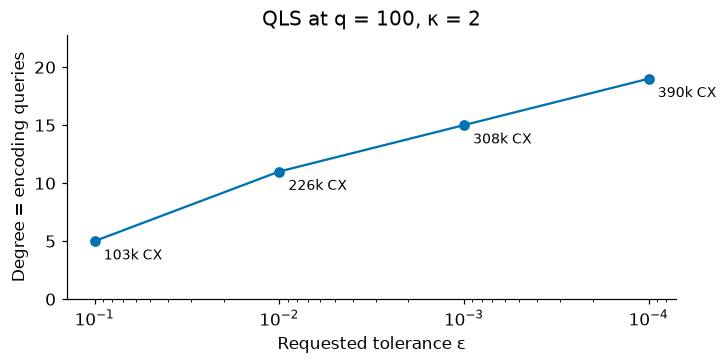

compare selected and estimated the four candidates in 0.17 s.


In [9]:
from fractions import Fraction

from numpy.polynomial import Chebyshev

from nwqlib import compare

TOLERANCES = (0.1, 0.01, 0.001, 0.0001)
sweep = timed("QLS compare", compare, screened_poisson(100), methods=[QLS(epsilon_inv=t) for t in TOLERANCES],
              context=CX, seed=7)


def exact_residual(coefficients, kappa, point):
    """κ x P(x) - 1 in exact rational arithmetic, for the stored Chebyshev coefficients of P and a binary64 point.

    Fraction(float) represents each stored coefficient and the point exactly. The Clenshaw recurrence
    b_k = c_k + 2x b_{k+1} - b_{k+2}, with zero terminal values, gives P(x) = c_0 + x b_1 - b_2 using only rational
    additions and multiplications, so the final cancellation in κ x P(x) - 1 introduces no rounding.
    """
    x = Fraction(float(point))
    c = tuple(Fraction(float(value)) for value in coefficients)
    b1 = b2 = Fraction(0)
    for value in reversed(c[1:]):
        b1, b2 = value + 2 * x * b1 - b2, b1
    return Fraction(float(kappa)) * x * (c[0] + x * b1 - b2) - 1


def candidate_residual(reconstruction):
    """Largest exact |κ x P(x) - 1| over x = 1/κ, x = 1 and the real numerical roots of its derivative in (1/κ, 1).

    NumPy's roots only choose the candidate points. The value is the residual at numerical stationary candidates,
    a lower bound on the supremum over [1/κ, 1] and a numerical diagnostic. It does not prove that every stationary
    point was found.
    """
    kappa = reconstruction.polynomial_kappa
    coefficients = reconstruction.polynomial.coefficients
    roots = (Chebyshev(coefficients) * Chebyshev([0, kappa]) - 1).deriv().roots()
    points = [1 / kappa, 1.0, *(float(root.real) for root in roots if np.isreal(root) and 1 / kappa < root.real < 1)]
    return max(abs(exact_residual(coefficients, kappa, x)) for x in points)


residual_checks = [(row.method.epsilon_inv, candidate_residual(row.plan.reconstruction),
                    Fraction(float(row.plan.reconstruction.polynomial.certificate))) for row in sweep.rows]
precision = [(row.method.epsilon_inv, row.plan.reconstruction.degree, row.plan.reconstruction.polynomial.certificate,
              float(candidate), number(row.estimate.quantity("cx")))
             for row, (_, candidate, _) in zip(sweep.rows, residual_checks, strict=True)]
show_table(precision, headers=("Requested tolerance ε", "Degree d = encoding queries", "Residual bound (stored)",
                               "Residual at numerical stationary candidates", "CX estimate per attempt"))
fig, ax = plt.subplots(figsize=(6.5, 3.2), layout="constrained")
ax.semilogx([row[0] for row in precision], [row[1] for row in precision], "o-", color="#0072B2")
for tolerance, degree, *_, cx_count in precision:
    ax.annotate(f"{cx_count / 1e3:.3g}k CX", (tolerance, degree), textcoords="offset points", xytext=(6, -12), fontsize=9)
ax.set(xlabel="Requested tolerance ε", ylabel="Degree = encoding queries", ylim=(0, 1.2 * precision[-1][1]),
       title=f"QLS at q = 100, κ = {qls[100].reconstruction.kappa_be:g}")
ax.invert_xaxis()
plt.show()
print(f"compare selected and estimated the four candidates in {SECONDS['QLS compare']:.2f} s.")

Each stored bound limits the relative error of the ideal inverse polynomial when the encoded spectrum lies in $[1/\kappa,1]$. It excludes the phase-fit error, the finite-precision arithmetic of the circuit, state preparation and measurement. In the table the exact residual at the stationary candidates lies below each stored bound.

<details><summary>How the residual bound is computed</summary>

The residual $R(x)=\kappa xP(x)-1$ has degree $d+1$. NWQLib bounds it by its maximum at $M$ affine Chebyshev-zero samples $x_j$ of $[1/\kappa,1]$ divided by $\cos[\pi(d+1)/(2M)]$ (Ehlich and Zeller, [doi:10.1007/BF01111276](https://doi.org/10.1007/BF01111276), Satz 2, Eqs. (12)–(14)), and an odd $P$ makes $R$ even, which covers the negative interval too. The exact residual at the numerical stationary candidates is a lower bound on the maximum and a crosscheck, not a replacement certificate.

</details>

## 2. Heat flow: an error budget for LCHS

LCHS meets an ideal error target of 0.01 for the physical vector with branches and Strang steps that do not depend on the ring size. The heat equation $du/dt=-Lu$ with $L=\tfrac14(2I-S-S^\dagger)$ runs on the same kind of ring until $T=1$, from a unit point source at site 0.

LCHS writes the propagator $e^{-LT}$ as an integral of the unitary evolutions $e^{-ikLT}$ over $k$, weighted by the kernel of An, Childs and Lin (arXiv:2312.03916v2, Eq. (7), $\beta=0.75$). A composite Gauss rule on $|k|\le K$ turns the integral into weighted branches on address qubits.

<details><summary>How the circuit applies each branch</summary>

$L$ is positive semidefinite with norm 1, so LCHS needs no spectral shift and no growth factor. For this periodic operator NWQLib splits the ring's bonds into even and odd terms and applies their symmetric Strang product with address-controlled rotations and shifts.

</details>

The kernel cutoff and quadrature receive 0.005 of the L2 target (`SELECTION_ALLOWANCE`), which LCHS divides equally between them, and the Strang product receives the other 0.005 (`STRANG_ALLOWANCE`). LCHS takes the smallest step count $r$ whose Strang bound $B/r^2$ meets 0.005.

Branches and bounds depend on $T\lVert L\rVert=1$ and the diffusion coefficient, not on the ring size, so the table holds at every q.

<details><summary>How the Strang bound is evaluated</summary>

The coefficient $B$ depends on the selected branches. LCHS evaluates $B$ in exact rational arithmetic from the stored nodes and branch weights, with each weight's modulus replaced by an upper value, and records $B/r^2$ rounded upward to a binary64 number.

</details>

Quantity,Value,Meaning and scope
Kernel,"An–Childs–Lin Eq. (7) (near_optimal_eq7), β = 0.75",Selected construction
Cutoff K,32.1994,Chosen by inverting the finite tail bound for its share
Gauss rule,18 panels × 15 points,Exact selected inventory
Branches / padded address slots,270 / 512,Exact selected inventory
Coefficient 1-norm,1.40522,"Sum of |branch weights|, not a success probability"
Kernel tail bound,0.0025,Analytic upper bound evaluated numerically
Quadrature bound,0.00230465,Analytic upper bound evaluated numerically
Strang coefficient B,14.0245,r² times the recorded bound at r
Strang steps r,53,"Smallest positive integer with B/r² ≤ 0.005, selected by LCHS"
Strang bound at r − 1 and at r,0.005187 and 0.004993,The previous integer misses the allowance


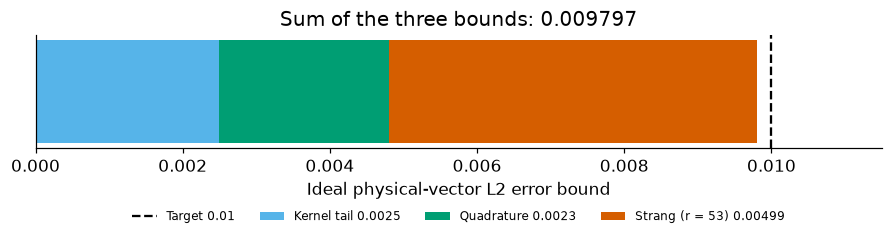

System qubits q,Total qubits,Branches,Strang steps r,Strang bound,CX upper bound per attempt,"plan, s","estimate, s"
80,89,270,53,0.00499,"1,448,218",0.0445,0.00631
90,99,270,53,0.00499,"1,809,678",0.0118,0.00726
100,109,270,53,0.00499,"2,213,538",0.0124,0.0383


In [10]:
from nwqlib.algorithms.lchs import resolve_lchs_coefficient_plan

coefficients = resolve_lchs_coefficient_plan(lchs[100])  # the selected k nodes, weights and Gauss rule
rule = coefficients.quadrature
bounds = {item.fact.quantity: item.fact.value.value for item in lchs[100].facts}
budget_sum = bounds["kernel_approximation"] + bounds["k_quadrature"] + bounds["trotter_synthesis"]
show_table([
    ("Kernel", f"An–Childs–Lin Eq. (7) ({coefficients.resolved_lchs_kernel.implementation}), β = "
               f"{coefficients.resolved_lchs_kernel.parameters['beta']:g}", "Selected construction"),
    ("Cutoff K", rule.range_k, "Chosen by inverting the finite tail bound for its share"),
    ("Gauss rule", f"{2 * rule.interval_count_each_side} panels × {rule.node_count} points", "Exact selected inventory"),
    ("Branches / padded address slots", f"{lchs[100].reconstruction.physical_branches} / "
                                        f"{lchs[100].reconstruction.padded_branches}", "Exact selected inventory"),
    ("Coefficient 1-norm", coefficients.coefficient_l1_norm, "Sum of |branch weights|, not a success probability"),
    ("Kernel tail bound", bounds["kernel_approximation"], "Analytic upper bound evaluated numerically"),
    ("Quadrature bound", bounds["k_quadrature"], "Analytic upper bound evaluated numerically"),
    ("Strang coefficient B", steps**2 * bounds["trotter_synthesis"], "r² times the recorded bound at r"),
    ("Strang steps r", steps, f"Smallest positive integer with B/r² ≤ {STRANG_ALLOWANCE:g}, selected by LCHS"),
    ("Strang bound at r − 1 and at r",
     f"{bounds['trotter_synthesis'] * steps**2 / (steps - 1)**2:.4g} and {bounds['trotter_synthesis']:.4g}",
     "The previous integer misses the allowance"),
    ("Sum of the three bounds", budget_sum, "Ideal vector error bound for the unit input, target 0.01"),
], digits=6)

fig, ax = plt.subplots(figsize=(8, 1.9), layout="constrained")
left = 0.0
for name, key, color in (("Kernel tail", "kernel_approximation", "#56B4E9"), ("Quadrature", "k_quadrature", "#009E73"),
                         (f"Strang (r = {steps})", "trotter_synthesis", "#D55E00")):
    ax.barh(0, bounds[key], left=left, color=color, label=f"{name} {bounds[key]:.3g}")
    left += bounds[key]
ax.axvline(0.01, color="k", linestyle="--", label="Target 0.01")
ax.set(xlim=(0, 0.0115), yticks=[], xlabel="Ideal physical-vector L2 error bound",
       title=f"Sum of the three bounds: {budget_sum:.4g}")
ax.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.45), frameon=False)
plt.show()

show_table([(q, number(lchs_cx[q].quantity("logical_width", location="logical_device")),
             lchs[q].reconstruction.physical_branches, lchs[q].reconstruction.step_counts[0],
             next(item.fact.value.value for item in lchs[q].facts if item.fact.quantity == "trotter_synthesis"),
             number(lchs_cx[q].quantity("cx")), SECONDS["LCHS plan", q], SECONDS["LCHS CX", q]) for q in SIZES],
           headers=("System qubits q", "Total qubits", "Branches", "Strang steps r", "Strang bound",
                    "CX upper bound per attempt", "plan, s", "estimate, s"))

The CX upper bound counts elementary gate slots of one coherent attempt before any gate cancellation or routing, with no repeat-until-success factor. NWQLib labels it `upper_bound` from the formula of the selected construction, and Appendix A reproduces it from an elementary count.

Because the Strang bound relaxes each nested commutator norm, a smaller r may already meet the 0.005 allowance for the circuit itself.

The cells request `NormSquared()`, a scalar readout of $\lVert u\rVert^2$. The 0.01 target is a bound on the physical vector, not on that scalar.

For a unit input and a vector error bound $\delta$, contractivity gives the separate ideal bound $\bigl|\lVert\tilde u\rVert^2-\lVert u\rVert^2\bigr|\le\delta(2+\delta)$. The finite-precision arithmetic of the circuit and sampling need their own contributions, which these plans leave unknown.

## 3. Eigenvalues: two spin chains with equal coefficient norms

Two Hamiltonians with equal coefficient 1-norms receive different product-formula step counts, because NWQLib selects the steps from the commutators of the terms. Two periodic chains of q spins share the same nearest-neighbor geometry,

$$H_{\rm I}=\tfrac32\sum_{j=0}^{q-1}(Z_jZ_{j+1}+X_j),\qquad H_{\rm H}=\sum_{j=0}^{q-1}(X_jX_{j+1}+Y_jY_{j+1}+Z_jZ_{j+1}),$$

with $j+1$ taken modulo q. Both coefficient 1-norms equal $3q$. The Ising chain has $2q$ Pauli terms and the Heisenberg chain $3q$. The terms enter the product formula in the order written, and the bounds below belong to that order.

QCELS (Ding and Lin, arXiv:2211.11973v2) estimates an eigenvalue from the Hadamard-test signal $\langle\psi|e^{-ip\tau H}|\psi\rangle$ for the powers $p=0,\dots,32$ of $e^{-i\tau H}$ with $\tau=0.005$, up to the longest time 0.16 (`QCELS_SCHEDULE`).

Each power needs two measurement settings, the real and imaginary parts, so the schedule has 66 settings and, at 1024 shots each (`SHOTS`), 67,584 shots. `estimate` counts the settings one after another (`batch_schedule="serial"`), so the total width is that of one circuit.

Each setting prepares its own circuit, so NWQLib selects the steps $r_p$ of each power on its own. Power $p$ takes the smallest count whose product-formula bound fits the allowance $\epsilon_p=0.001$ (`POWER_ALLOWANCE`) at the time $t_p=p\tau$. Planning refuses a power whose complete recorded bound exceeds 0.001.

<details><summary>How the step count and its bound are computed</summary>

One second-order step of time $h$ has error at most $W|h|^3$ (Childs et al., arXiv:1912.08854v3, Prop. 16, Eq. (152)), where $W$ sums the nested commutators of the ordered Pauli terms. NWQLib evaluates the full commutator-count coefficient with scaled binary64 products and sums rounded upward. The resulting rational coefficient $W_{\rm up}$ bounds the exact coefficient $W$ and, for these chains, lies within the relative window derived in Appendix A. With the dropped coefficient mass $d$ of pruned terms, which is zero for these chains, power $p$ takes the smallest count whose ideal bound $W_{\rm up}|t_p|^3/r_p^2$ fits the remaining allowance,

$$r_p=\max\Bigl(1,\Bigl\lceil\sqrt{W_{\rm up}|t_p|^3/(\epsilon_p-|t_p|d)}\Bigr\rceil\Bigr),$$

evaluated by exact rational inversion. Each saved power bound adds pruning, represented-time displacement, identity-phase formation and leaf-angle formation to the product-formula error of the emitted step, and is recorded rounded upward. One commutator count serves every power. Its work and the exact arithmetic of the per-power check are counted against `max_work` as separate stages, and both fit the default of $10^9$ (Appendix D).

</details>

`estimate` then counts the logical operations and CX gates of every setting and shot. One step costs $4\sum_j w_j$ CX gates, with $w_j$ the number of qubits that term $j$ acts on, which is $12q$ for the Ising chain and $24q$ for the Heisenberg chain.

This count follows the decomposition that Qiskit 2.5.2 emits, in which a controlled rotation of a Pauli term on $w$ qubits costs $2w$ CX gates. The counts are exact for that decomposition, before optimization and routing.

The product state $|0101\ldots\rangle$ gives a reproducible workload with no established overlap with the ground state. These counts therefore price the selected QCELS experiments, not a certified ground-energy estimate.

Since $\tau\cdot3q\le1.5<\pi$, the spectral enclosure suffices to exclude phase wrapping of the integer powers. It does not establish spectral identification or estimator accuracy.

Chain,q,Pauli terms,Coefficient 1-norm,Steps at p = 32,Steps over all powers,"Logical operations, all shots","CX gates, all shots","plan, s","estimate, s"
Ising,80,160,240,47,640,"422,336,512","1,258,291,200",0.0396,0.0952
Ising,90,180,270,50,680,"504,594,432","1,504,051,200",0.0418,0.134
Ising,100,200,300,53,717,"590,948,352","1,762,099,200",0.0447,0.0918
Heisenberg,80,240,240,58,780,"769,677,312","3,067,084,800",0.0501,0.13
Heisenberg,90,270,270,61,825,"915,628,032","3,649,536,000",0.0554,0.0939
Heisenberg,100,300,300,65,870,"1,072,637,952","4,276,224,000",0.0621,0.131


Every plan has 66 measurement settings, 67,584 shots and q + 1 qubits.


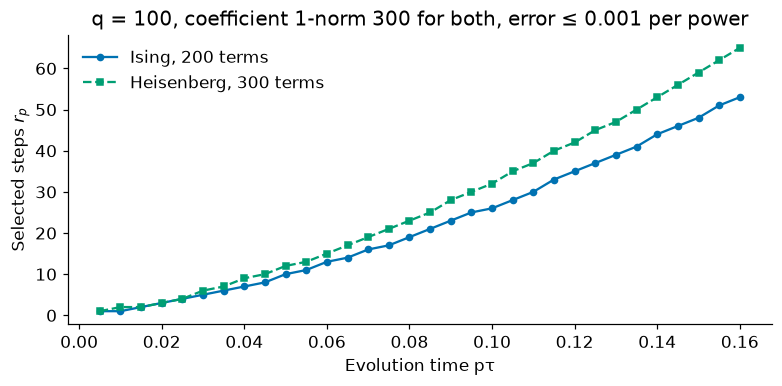

In [11]:
show_table([(model, q, len(qpe[model, q].reconstruction.pauli_terms), qpe[model, q].reconstruction.spectral_radius_bound,
             qpe[model, q].reconstruction.powers[-1].steps, sum(power.steps for power in qpe[model, q].reconstruction.powers[1:]),
             number(qpe_fold[model, q].quantity("operations")), number(qpe_cx[model, q].quantity("cx")),
             SECONDS[model, "plan", q], SECONDS[model, "estimate", q] + SECONDS[model, "CX", q])
            for model in ("Ising", "Heisenberg") for q in SIZES],
           headers=("Chain", "q", "Pauli terms", "Coefficient 1-norm", "Steps at p = 32", "Steps over all powers",
                    "Logical operations, all shots", "CX gates, all shots", "plan, s", "estimate, s"))
workload = {(number(qpe_fold[key].quantity("settings")), number(qpe_fold[key].quantity("shots")),
             number(qpe_fold[key].quantity("logical_width", location="logical_device")) - key[1]) for key in qpe}
print("Every plan has " + ", or ".join(f"{settings} measurement settings, {shots:,} shots and q + {extra} qubits"
                                      for settings, shots, extra in sorted(workload)) + ".")

fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
for model, color, marker, style in (("Ising", "#0072B2", "o", "-"), ("Heisenberg", "#009E73", "s", "--")):
    powers = qpe[model, 100].reconstruction.powers[1:]
    ax.plot([power.evolution_time for power in powers], [power.steps for power in powers], marker=marker,
            markersize=4, linestyle=style, color=color, label=f"{model}, {len(qpe[model, 100].reconstruction.pauli_terms)} terms")
ax.set(xlabel="Evolution time pτ", ylabel="Selected steps $r_p$",
       title=f"q = 100, coefficient 1-norm {qpe['Ising', 100].reconstruction.spectral_radius_bound:g} for both, "
             f"error ≤ {POWER_ALLOWANCE:g} per power")
ax.legend(frameon=False)
plt.show()

The Heisenberg chain needs more steps than the Ising chain at the longer times, although both have the same coefficient 1-norm. A step-count rule that used only the 1-norm would give them the same counts.

**Does the step count follow the commutators?** Replacing each Ising field $X_j$ by $Z_j$ keeps 200 terms, the coefficient 1-norm 300 and the schedule, and makes all terms commute. The cell plans this chain.

In [12]:
commuting_terms = [term for j in range(100)
                   for term in ((pauli_label(100, (j, (j + 1) % 100), "Z"), 1.5), (pauli_label(100, (j,), "Z"), 1.5))]
commuting = plan(Eigenproblem(A=ingest_pauli(commuting_terms, num_qubits=100)), method=neel_qcels[100], shots=SHOTS, seed=7)
commuting_steps = [power.steps for power in commuting.reconstruction.powers[1:]]
commuting_bound = max(power.total_error for power in commuting.reconstruction.powers)
print(f"{len(commuting_terms)} commuting terms, coefficient 1-norm {commuting.reconstruction.spectral_radius_bound:g}: "
      + (f"{commuting_steps[0]} step at every power, " if len(set(commuting_steps)) == 1
         else f"{min(commuting_steps)} to {max(commuting_steps)} steps per power, ")
      + f"{sum(commuting_steps)} over the {len(commuting_steps)} powers, "
      f"largest recorded bound {commuting_bound:.3g}")

200 commuting terms, coefficient 1-norm 300: 1 step at every power, 32 over the 32 powers, largest recorded bound 6.68e-15


With commuting terms the ideal product formula is exact, so every power takes the minimum of one step, while the recorded bound keeps only the represented-time and parameter-formation terms. The step selection uses the commutators and is not a disguised coefficient-norm estimate.

<details><summary>Why QCELS, and what the other QPE methods would need</summary>

| Method | What it needs and reports | Use in this notebook |
| --- | --- | --- |
| QCELS | A fixed paired schedule and a finite least-squares search. No uncertainty interval. Its published guarantees for a dominant overlap and a multilevel schedule do not transfer automatically to this workload. | The main example, because its consecutive power schedule is deterministic and gives a transparent workload. |
| SPE | An asserted overlap lower bound, random Fourier draws and a valid filter domain. It targets the lowest prepared spectral support, and the default sample count does not certify the grid search. | Omitted, because these chains have no verified overlap assumption. |
| RFE | Random powers, finite Fourier resolution, and an eigenstate and sample-budget assumption for its published precision theorem, which the default 97 draws do not meet. | A valid alternative workload, whose random schedule adds variation without helping the commutator comparison. |
| RWPE | Continuous-time Hamiltonian access, a Gaussian prior and one-shot adaptive updates. The Gaussian width does not certify coverage, and future feedback points are not predicted. | Omitted from this static demonstration. |

The [QPE guide](../docs/algorithms/qpe.md) describes each method. For these plans the QPE error model leaves spectral identification, aliasing, sampling, the estimator model, the finite grid, controlled evolution and the roundoff of the circuit implementation unknown. The per-power bounds and the aliasing enclosure are not propagated into a final energy-error certificate.

</details>

## 4. QHD: one-hot versus binary encoding

Binary encoding needs fewer qubits and rotations than one-hot for one QHD step on this quadratic. Quantum Hamiltonian descent (QHD, Leng et al., arXiv:2303.01471v1) seeks a minimizer of a function $f$ by evolving a wave function under the time-dependent Hamiltonian $a(t)\,H_{\rm kin}+b(t)\,f$, where $H_{\rm kin}$ is the kinetic operator.

NWQLib discretizes each variable on $K$ grid points, and the encoding decides how a grid index is stored. One-hot uses $K$ qubits per variable with exactly one qubit set to 1, and binary uses $\log_2K$ qubits per variable, which is the tradeoff that Liu et al. ([arXiv:2607.16996v1](https://arxiv.org/html/2607.16996v1), Sections III–IV) study. We price one step for the coupled quadratic

$$f(x,y,z)=(x-\tfrac14)^2+(y-\tfrac14)^2+(z-\tfrac14)^2+\tfrac14[(x-y)^2+(y-z)^2],\qquad (x,y,z)\in[0,1)^3.$$

The grid has periodic finite-difference kinetics and spacing $1/K$. Both encodings start uniformly and use one first-order step from 0 to 0.001, with midpoint weights $a(t)=2/(1+t^3)$ and $b(t)=2t^3$. Counts include preparation and exclude routing, with no rotation pruning and no removal of rotations near Clifford angles.

<details><summary>How each encoding applies its phases and counts its rotations</summary>

Binary applies each phase table either as Walsh rotations, one Z-string rotation per nonzero Walsh coefficient, or as a dense diagonal over all basis states of its registers, and takes whichever needs fewer CX gates. It also uses a full QFT with bit-reversal relabeling for the kinetic factor. One-hot classifies every emitted angle exactly as arbitrary, exact T or Clifford. Binary instead bounds its rotation slots, the places where a rotation can appear before its angle is classified, so its formula includes exact T angles and slots that a dense diagonal leaves unused.

</details>

Each plan requests `shots=1`. A QHD batch of measurement counts with $S$ repetitions has $S$ shots and one setting, and its hardware cost multiplies the per-circuit resources by $S$.

Exact probability or amplitude readout has one setting and one exact evaluation, with no sampled shots. A simulated exact evaluation does not supply the hardware budget of $S$ repetitions.

In [13]:
# Display helpers for Section 4. Nothing in this cell calls NWQLib.
QHD_ENCODINGS = {"one_hot": "One-hot", "binary": "Binary"}
SUPERSCRIPT = str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹")


def qhd_rotation_cell(quantity):
    """An arbitrary-rotation formula with its label: an exact count, or an upper bound marked with ≤."""
    value = format_value(number(quantity))
    return {"exact": f"{value}, exact count", "upper_bound": f"≤ {value}, upper bound"}.get(quantity.interpretation, value)


def qhd_bound_text(value):
    """An evolution bound to three significant digits. The value 2 is the cap on the distance of two unitaries."""
    if value == 2:
        return "2, uninformative cap"
    if value >= 1e-3:
        return f"{value:#.3g}"
    mantissa, exponent = f"{value:.2e}".split("e")
    return f"{mantissa} × 10{str(int(exponent)).translate(SUPERSCRIPT)}"


def show_qhd_table(grid_points, widths, cx, rotations, ledgers, acquisitions):
    """Show the Section 4 result sentence for the largest grid and the table of all rows."""
    top_k = grid_points[-1]
    counts = " or ".join(f"{shots} shot{'s' * (shots != 1)}, {settings} setting{'s' * (settings != 1)} and "
                          f"{exact} exact evaluation{'s' * (exact != 1)}" for shots, settings, exact in sorted(acquisitions))
    display(HTML(f"<p>For the same {top_k}-point grid in each of three variables, one-hot uses "
                 f"{number(widths[top_k, 'one_hot'])} logical qubits and binary uses {number(widths[top_k, 'binary'])}. "
                 f"The estimate of each plan counts {counts}.</p>"))
    show_table([(k, QHD_ENCODINGS[encoding], number(widths[k, encoding]), number(cx[k, encoding]),
                 qhd_rotation_cell(rotations[k, encoding]), qhd_bound_text(ledgers[k, encoding].evolution.evolution))
                for k in grid_points for encoding in QHD_ENCODINGS],
               headers=("K", "Encoding", "Logical qubits, exact count", "CX, upper bound", "Arbitrary rotations",
                        "Ideal-evolution bound, rounded"))

In [14]:
import sympy as sp

from nwqlib import Optimization
from nwqlib.algorithms.qhd import BinarySynthesis, CubicSchedule, QHD, UniformState, circuit_resources

qhd_x, qhd_y, qhd_z = sp.symbols("x y z")
qhd_objective = sum((v - sp.Rational(1, 4)) ** 2 for v in (qhd_x, qhd_y, qhd_z))
qhd_objective += ((qhd_x - qhd_y) ** 2 + (qhd_y - qhd_z) ** 2) / 4
qhd_problem = Optimization(objective=qhd_objective, variables=(qhd_x, qhd_y, qhd_z), bounds=((0.0, 1.0),) * 3)
QHD_GRID_POINTS = (8, 16, 32)


def qhd_method(k, encoding):
    """One first-order QHD step from 0 to 0.001 on K grid points per variable, from the uniform state, without pruning."""
    return QHD(num_grid_points=k, encoding=encoding, boundary="periodic", kinetic_model="finite_difference",
               num_steps=1, total_time=0.001, schedule=CubicSchedule(s=1.0), coefficient_rule="midpoint",
               trotter_order=1, initial_state=UniformState(), initial_state_preparation="structured",
               rotation_threshold=0.0, binary_synthesis=BinarySynthesis())


# A QHD circuit has one measurement setting. With shots=1 the estimate counts one
# circuit repetition, one shot and one setting. Exact probability or
# amplitude readout counts one exact evaluation and no sampled shots.
# Per-circuit CX and rotation formulas describe the selected construction.
# The CX formula comes from the cx context, the width and the arbitrary-rotation formula from the selected_logical context,
# and the error sources from circuit_resources.
qhd_plans, qhd_cx, qhd_logical, qhd_ledgers = {}, {}, {}, {}
for qhd_key in ((k, encoding) for k in QHD_GRID_POINTS for encoding in QHD_ENCODINGS):
    qhd_plans[qhd_key] = plan(qhd_problem, method=qhd_method(*qhd_key), execution="quantum", shots=1, seed=7)
    qhd_cx[qhd_key] = estimate(qhd_plans[qhd_key], context=CX)
    qhd_logical[qhd_key] = estimate(qhd_plans[qhd_key], context=ResourceContext(basis="selected_logical"))
    qhd_ledgers[qhd_key] = circuit_resources(qhd_plans[qhd_key])
show_qhd_table(QHD_GRID_POINTS, {key: value.quantity("logical_width", location="logical_device") for key, value in qhd_logical.items()},
               {key: value.quantity("cx") for key, value in qhd_cx.items()},
               {key: value.quantity("arbitrary_rotations") for key, value in qhd_logical.items()}, qhd_ledgers,
               {tuple(number(value.quantity(metric)) for metric in ("shots", "settings", "exact_evaluations"))
                for value in qhd_cx.values()})

K,Encoding,"Logical qubits, exact count","CX, upper bound",Arbitrary rotations,"Ideal-evolution bound, rounded"
8,One-hot,24,307,"399, exact count",0.0430
8,Binary,9,108,"≤ 123, upper bound",1.94 × 10⁻¹⁰
16,One-hot,48,"1,131","1,575, exact count",1.47
16,Binary,12,214,"≤ 231, upper bound",7.70 × 10⁻¹⁰
32,One-hot,96,"4,315","6,231, exact count","2, uninformative cap"
32,Binary,15,370,"≤ 388, upper bound",3.08 × 10⁻⁹


Binary saves qubits and rotations here, consistent with the tradeoff in Liu et al. (arXiv:2607.16996v1, Sections III–IV). Its sparse quadratic potential also keeps CX costs low. This is a three-variable illustration, not a reproduction of the paper's benchmark table.

The finite model has $K^3$ states, only 32,768 at $K=32$, so the 96-qubit one-hot representation does not establish classical intractability.

Each evolution bound limits the operator-norm distance, including global phase, from the ideal split step to the exact time-ordered evolution of the stored finite model on its valid encoded states. The different bounds reflect the two constructions, and neither measures achieved accuracy.

<details><summary>Why the one-hot bound grows faster, and what the bound leaves out</summary>

One-hot also splits the kinetic factor into its links, whose commutator sum grows like $K^5$, while binary applies the whole kinetic factor in its Fourier basis. A bound at the unitary-distance cap gives no useful accuracy resolution. Preparation, angle formation, dense-diagonal construction, synthesis and compiler errors have separate statuses. An unavailable dense-diagonal or compiler component prevents a certified total for the circuit, and a requested synthesis allowance is not an achieved compiler error. The error sources of the 32-point plans in Appendix A list every status, with the dense-diagonal construction under `diagonal_wrap`. Some component bounds assume one-ulp sine and cosine errors and a correctly rounded `math.fsum`. No optimization success probability or continuum error is certified.

</details>

The single initial step gives a small, reproducible workload for comparing the circuit constructions, not evidence that the state reaches the minimum. Appendix A derives the counts and the evolution bound independently, and Appendix E compiles three small circuits.

The quadratic is nonnegative and has its unique minimum at $(\tfrac14,\tfrac14,\tfrac14)$, which lies on every selected grid. The periodic kinetic boundary does not make the polynomial periodic, and the evolution bound includes its jump across the wrap edge. The grid and time step stay fixed between encodings, and refining $K$ does not impose a common error allowance.

## 5. Eigenvalues with GCiM: a fixed trial basis for a parity Hamiltonian

A fixed GCiM trial basis of two product states needs eight measurement settings at every size from 80 to 100 qubits. The generator-coordinate-inspired method (GCiM, Zheng et al., arXiv:2312.07691v3) approximates eigenvalues of a Hamiltonian $A$ by projecting it onto the span of a few trial states $\phi_i$.

With $H_{ij}=\langle\phi_i|A|\phi_j\rangle$ and $S_{ij}=\langle\phi_i|\phi_j\rangle$ it solves the generalized eigenproblem $Hc=ESc$, whose size is the number $m$ of trial states, not $2^q$. `FixedGCIM` takes the trial states from the user.

<details><summary>How the matrix entries are measured</summary>

With finite shots it prepares each off-diagonal pair of trial states as one joint state of an ancilla qubit and the system, and measures the ancilla in X or Y together with one qubit-wise-commuting group of Pauli terms per setting, while each diagonal entry measures its trial state once per group.

</details>

The example is the parity Hamiltonian $A=-Z^{\otimes q}-0.7\,X^{\otimes q}$, in which every system qubit participates, with the two product trial states $(\cos\theta\,|0\rangle+\sin\theta\,|1\rangle)^{\otimes q}$ at $\theta=\pi/8$ and $3\pi/8$.

The workload has $m=2$ trial states, $L=2$ nonidentity Pauli terms and 1024 shots per setting (`SHOTS`), measured one after another. Normalized trial states fix $S_{ii}=1$. The two terms act with different letters on every qubit, so they form $G=2$ qubit-wise-commuting groups, and the plan has $m^2G$ measurement settings (Appendix A).

In [15]:
show_table([(q, number(gcim_cx[q].quantity("logical_width", location="logical_device")),
             number(gcim_cx[q].quantity("settings")), number(gcim_cx[q].quantity("shots")),
             number(gcim_cx[q].quantity("cx")), SECONDS["GCiM plan", q], SECONDS["GCiM CX", q]) for q in SIZES],
           headers=("System qubits q", "Total qubits, with the ancilla qubit", "Settings", "Shots",
                    "CX upper bound, all shots", "plan, s", "estimate, s"))

System qubits q,"Total qubits, with the ancilla qubit",Settings,Shots,"CX upper bound, all shots","plan, s","estimate, s"
80,81,8,"8,192","2,621,440",0.0248,0.00651
90,91,8,"8,192","2,949,120",0.00278,0.0067
100,101,8,"8,192","3,276,800",0.00314,0.0062


The four off-diagonal settings cost at most $32q$ CX per execution of all settings, or $32q\times1024$ over all shots. The four diagonal settings and the one-qubit readout rotations contribute zero CX. These counts precede hardware routing.

<details><summary>Where the bound comes from, and how tight it is</summary>

Each off-diagonal setting contains two controlled product preparations, each bounded by $4q$ CX under the selected one-qubit preparation formula. Appendix E compiles the three-qubit plan to 48 CX per complete execution, half its 96-CX bound, because these real product states use one two-CX controlled RY per site. T gates and physical resources are unavailable because the selected formulas do not supply them.

</details>

These are measurement costs, and they certify no energy. Shot noise, the conditioning of the overlap matrix $S$, the error of the two-state trial space and whether the lowest projected eigenvalue identifies the full-space ground state remain unresolved.

With the same two trial states, the open Ising chain $-\sum_jZ_jZ_{j+1}-0.7\sum_jX_j$ on 80 qubits has 159 Pauli terms, but its $ZZ$ terms and its $X$ terms form two qubit-wise-commuting groups, so its plan also has eight settings.

## Summary

The table collects the 100-qubit plans. Each family solves a different problem, and its main resource has a different meaning, so the rows are not a ranking.

In [16]:
top = SIZES[-1]
largest_bound = {model: max(power.total_error for power in qpe[model, top].reconstruction.powers) for model in ("Ising", "Heisenberg")}
show_table([
    ("QLS, screened Poisson ring with κ = 2", f"{top} / {number(qls_cx[top].quantity('logical_width', location='logical_device'))}",
     f"degree {qls[top].reconstruction.degree} = {qls[top].reconstruction.degree} encoding queries, "
     f"{format_value(number(qls_cx[top].quantity('cx')))} CX",
     "Exact degree and query count. CX is an estimate per coherent attempt."),
    ("LCHS, heat flow on a ring", f"{top} / {number(lchs_cx[top].quantity('logical_width', location='logical_device'))}",
     f"{lchs[top].reconstruction.physical_branches} branches, {lchs[top].reconstruction.padded_branches} address slots, "
     f"{steps} steps, CX ≤ {number(lchs_cx[top].quantity('cx')):,}",
     f"Exact inventory and an elementary-slot CX upper bound. The ideal vector-error bounds sum to {budget_sum:.4g}."),
    *((f"QCELS, {model} ring", f"{top} / {number(qpe_fold[model, top].quantity('logical_width', location='logical_device'))}",
       f"{qpe[model, top].reconstruction.powers[-1].steps} steps at the longest power, "
       f"{number(qpe_fold[model, top].quantity('shots')):,} shots, "
       f"{number(qpe_fold[model, top].quantity('operations')):,} logical operations, "
       f"{number(qpe_cx[model, top].quantity('cx')):,} CX",
       "Exact planned settings and shots, and exact counts for the emitted decomposition, before optimization and routing. "
       f"The largest per-power bound is {largest_bound[model]:.3g}.")
      for model in ("Ising", "Heisenberg")),
    ("GCiM, parity Hamiltonian, two product trial states",
     f"{top} / {number(gcim_cx[top].quantity('logical_width', location='logical_device'))}",
     f"{number(gcim_cx[top].quantity('settings'))} settings, {number(gcim_cx[top].quantity('shots')):,} shots, "
     f"CX ≤ {number(gcim_cx[top].quantity('cx')):,}",
     "Exact settings and shots, and a CX upper bound over all shots. Shot noise, overlap conditioning, trial-space "
     "error and ground-state identification are unresolved."),
], headers=("Family and instance", "System / total qubits", "Main resource", "Evidence and scope"))

Family and instance,System / total qubits,Main resource,Evidence and scope
"QLS, screened Poisson ring with κ = 2",100 / 104,"degree 11 = 11 encoding queries, 225,734 CX",Exact degree and query count. CX is an estimate per coherent attempt.
"LCHS, heat flow on a ring",100 / 109,"270 branches, 512 address slots, 53 steps, CX ≤ 2,213,538",Exact inventory and an elementary-slot CX upper bound. The ideal vector-error bounds sum to 0.009797.
"QCELS, Ising ring",100 / 101,"53 steps at the longest power, 67,584 shots, 590,948,352 logical operations, 1,762,099,200 CX","Exact planned settings and shots, and exact counts for the emitted decomposition, before optimization and routing. The largest per-power bound is 0.000997."
"QCELS, Heisenberg ring",100 / 101,"65 steps at the longest power, 67,584 shots, 1,072,637,952 logical operations, 4,276,224,000 CX","Exact planned settings and shots, and exact counts for the emitted decomposition, before optimization and routing. The largest per-power bound is 0.000999."
"GCiM, parity Hamiltonian, two product trial states",100 / 101,"8 settings, 8,192 shots, CX ≤ 3,276,800","Exact settings and shots, and a CX upper bound over all shots. Shot noise, overlap conditioning, trial-space error and ground-state identification are unresolved."


<details><summary>What these counts and bounds establish</summary>

The widths and shot counts describe the selected constructions. QLS CX is a selected estimate, LCHS CX is an elementary-slot upper bound, QPE CX is an exact count for the emitted decomposition over all shots, and QPE reports per-power product-formula bounds. The QLS residual and the LCHS kernel-tail and quadrature bounds are evaluated in binary64 arithmetic without an interval enclosure of every rounding operation. The LCHS Strang bound is evaluated rationally from its enclosed weights and recorded rounded upward. QPE's commutator coefficient is an upward-rounded bound within the relative window derived in Appendix A for these chains. Time and step-count factors are combined with that rational upper coefficient exactly before the recorded bound is rounded upward. QHD evaluates its finite-model evolution bound outward, rounding upward, although some of its components assume one-ulp sine and cosine and a correctly rounded `math.fsum`.

The QLS polynomial residual bounds its ideal inverse-polynomial component. The LCHS error sum bounds the ideal physical-vector error for the stated unit input. The QPE controlled-evolution allowance bounds a unitary power, not the fitted energy. The QHD evolution bound limits the ideal split step's distance from the exact evolution of the stored finite model, not an optimization outcome or the continuum problem. GCiM counts its measurement settings and shots exactly and bounds their CX gates, and it certifies no energy. Preparation overlap, postselection cost, the finite-precision arithmetic of the circuit and final measurement or estimator error require separate evidence. These plans do not establish total physical-output accuracy, ground-state identity, physical-qubit requirements or execution time.

The state-vector memory result applies to an unpartitioned complex128 representation. It does not exclude tensor methods or classical algorithms that exploit these problems' structure.

</details>

## Appendix

### A. Formulas and independent checks

**CX counts.** Each QLS encoding query of the three-band stencil uses two address qubits. It costs a quantum Fourier transform and its inverse, $2q(q-1)$ CX for their controlled phases and $6\lfloor q/2\rfloor$ for their swaps, $4q$ for q four-entry uniformly controlled RZ gates, and 6 for the coefficient diagonal and its preparation pair. Each of the $d+1$ projector phases adds two two-control X gates at 6 CX each and two pair-controlled CX gates. Together,

$$C_{\rm QLS}(q,d)=d\bigl[2q(q-1)+6\lfloor q/2\rfloor+4q+6\bigr]+14(d+1).$$

The LCHS circuit with $P$ padded address slots prepares the branch weights and applies their address phases at $3(P-2)$ CX. Each Strang step applies three uniformly controlled rotations and two shifts, each shift with a Fourier-transform pair, so with $r$ steps

$$C_{\rm LCHS}=3(P-2)+r\bigl[3P+4q(q-1)+12\lfloor q/2\rfloor\bigr].$$

A QPE Suzuki step stores $2L$ controlled Pauli rotations for $L$ terms, and each power has two quadratures. Each shot also applies $q/2$ occupation X gates, two H gates and one quadrature phase, while measurement is counted separately. Over 1024 shots per setting and the 66 settings, the composite logical operations and the CX gates, with $W_{\rm supp}=\sum_jw_j$ the total support of the terms, are

$$N_{\rm ops}=1024\Bigl[4L\sum_{p=1}^{32}r_p+66(q/2+3)\Bigr],\qquad C_{\rm QPE}=1024\cdot2\cdot4W_{\rm supp}\sum_{p=1}^{32}r_p,$$

since the occupation preparation, the Hadamard gates and the phases cost no CX gates.

**LCHS bounds.** With $C_\beta=2\pi e^{-2^\beta}$ and $x=\cos(\beta\pi/2)K^\beta$, the kernel tail beyond $|k|=K$ is at most $2e^{-x}/(\beta C_\beta x)$, from An, Childs and Lin (arXiv:2312.03916v2, Eqs. (185)–(186)) with $E_1(x)\le e^{-x}/x$. Each Gauss panel of width $h$ with $Q$ points obeys the analytic bound of Trefethen's *Approximation Theory and Approximation Practice* (ISBN 978-1-61197-239-9, Theorem 19.3, Eq. (19.8), with $n=Q-1$) in the strip $|\operatorname{Im}k|\le0.9$, where the kernel is at most $1/(0.1C_\beta)$ and the evolution at most $e^{0.9T\lVert L\rVert}$. Mapping that strip to the panel's Bernstein ellipse $\rho=e^{\operatorname{asinh}(1.8/h)}$ and summing over the panels gives $64Ke^{0.9T\lVert L\rVert}/\bigl(15\cdot0.1\,C_\beta(\rho^2-1)\rho^{2(Q-1)}\bigr)$. For the Strang product, relaxing each nested commutator with $\lVert[X,Y]\rVert\le2\lVert X\rVert\lVert Y\rVert$ in Childs et al. (arXiv:1912.08854v3, Prop. 16, Eq. (152)), telescoping the $r$ unitary steps and summing the branch errors with the weights $|c_j|$ gives, for diffusion coefficient $\delta_L=1/4$,

$$B=\frac{T^3}{3}\sum_j|c_j|\,(2|k_j|\delta_L)^3,\qquad E_{\rm Strang}(r)\le B/r^2.$$

**QPE commutator coefficient.** For ordered Pauli terms of equal coefficient magnitude $g$, two terms anticommute when their supports overlap on an odd number of sites with different Pauli letters. Every surviving commutator of Pauli terms has norm 2, and every surviving nested commutator norm 4. With $C_{24}$ the number of anticommuting pairs $i<j$ and $C_{12}$ the number of triples $i<j$, $k>i$ with $H_i,H_j$ anticommuting and $H_k$ anticommuting with exactly one of them, the second-order bound of Childs et al. (arXiv:1912.08854v3, Prop. 16, Eq. (152)) becomes $Wr_p|h|^3$ for $r_p$ steps of time $h$, with the subscripts naming the prefactors 1/12 and 1/24 of that bound,

$$W=g^3\left(\frac{C_{12}}{3}+\frac{C_{24}}{6}\right).$$

The cell evaluates each relation from the problem data or the selected records, independently of NWQLib's own evaluation, and compares. The LCHS coefficient $B$ is compared with the record of a one-step plan of the same branches, since the selected plan records $B/r^2$. It evaluates the LCHS bounds in binary64 arithmetic. NWQLib evaluates the kernel-tail and quadrature bounds in binary64 arithmetic as well, in other forms of the same formulas, and the Strang coefficient exactly from upper values of the weight moduli, rounding its records upward. The two evaluations of each LCHS bound therefore agree only up to rounding, and each comparison has a window in units of $u=2^{-53}$, derived for these inputs from the operations of both paths. The independent Strang step count must hold for every coefficient within $15u$ of the independent value, an interval that contains the exact coefficient LCHS inverts. The independent QPE oracle evaluates the full Pauli-triangle coefficient $W$ in exact rational arithmetic from the stored binary64 coefficients. NWQLib's coefficient satisfies $W\le W_{\rm up}\le W(1+\delta)$, where $\delta$ follows from power-of-two scaling, outward multiplication and the two levels of block reduction. The QPE record stores $W_{\rm up}$, the reduction block, the commutator-count variant and the coefficient arithmetic, and the cell reads them from the record. For each power $p\ge1$ the cell then recomputes the step count $r_p$ of Section 3 in exact rational arithmetic from $W_{\rm up}$, the stored binary64 time of the power and the allowance, together with the count that the exact coefficient $W$ would give. With the emitted binary64 step time $h$, the stored time divided by $r_p$, the emitted half angles $a_j$, the coefficient sum $M=\sum_j|c_j|$ and $A=2\sum_j|a_j-hc_j/2|$, it evaluates the complete power bound

$$B_p=|t_p|d+r_p\bigl(W_{\rm up}|h|^3+A\bigr)+M\,|r_ph-t_p|+|\phi+t_pc_I|$$

exactly from the stored binary64 values, with $t_p=p\,\tau$ formed exactly, and compares its upward rounding with the recorded bound. Here $d$, the identity coefficient $c_I$ and the emitted identity phase $\phi=-p\tau c_I$ are zero for these chains. The recorded bound must also lie between $B_p$ evaluated with $W$ and with $W(1+\delta)$, each rounded upward. The recheck work that planning counts against `max_work` before this exact arithmetic is NWQLib's own value, shown without an independent check.

In [17]:
from fractions import Fraction as Q
from math import asinh, ceil, cos, exp, frexp, fsum, inf, isclose, isqrt, nextafter, pi

from nwqlib.algorithms.qpe.powers import independent_recheck_work, rotation_schedule


def qls_cx_formula(q, d):
    """C_QLS(q, d) = d [2q(q-1) + 6 floor(q/2) + 4q + 6] + 14(d + 1), the elementary count above."""
    return d * (2 * q * (q - 1) + 6 * (q // 2) + 4 * q + 6) + 14 * (d + 1)


def lchs_cx_formula(q, slots, r):
    """C_LCHS = 3(P - 2) + r [3P + 4q(q-1) + 12 floor(q/2)] for P padded address slots and r Strang steps."""
    return 3 * (slots - 2) + r * (3 * slots + 4 * q * (q - 1) + 12 * (q // 2))


qls_cx_checks = [(f"QLS, q = {q}, d = {qls[q].reconstruction.degree}", qls_cx_formula(q, qls[q].reconstruction.degree),
                  number(qls_cx[q].quantity("cx"))) for q in SIZES]
qls_cx_checks += [(f"QLS, q = 100, ε = {row.method.epsilon_inv:g}, d = {row.plan.reconstruction.degree}",
                   qls_cx_formula(100, row.plan.reconstruction.degree), number(row.estimate.quantity("cx")))
                  for row in sweep.rows]
lchs_cx_checks = [(f"LCHS, q = {q}, r = {steps}", lchs_cx_formula(q, lchs[q].reconstruction.padded_branches, steps),
                   number(lchs_cx[q].quantity("cx"))) for q in SIZES]
qpe_count_checks = []
for (model, q), selected_qpe in qpe.items():
    terms, step_sum = chain_terms(q, model), sum(power.steps for power in selected_qpe.reconstruction.powers[1:])
    support = sum(sum(letter != "I" for letter in label) for label, _ in terms)
    qpe_count_checks += [
        (f"QPE {model} operations, q = {q}", SHOTS * (4 * len(terms) * step_sum + 66 * (q // 2 + 3)),
         number(qpe_fold[model, q].quantity("operations"))),
        (f"QPE {model} CX, q = {q}", SHOTS * 2 * 4 * support * step_sum, number(qpe_cx[model, q].quantity("cx")))]
show_table([(name, formula, library, "equal" if formula == library else "different")
            for name, formula, library in qls_cx_checks + lchs_cx_checks + qpe_count_checks],
           headers=("Construction", "Elementary count", "NWQLib value", "Comparison"))

# LCHS bounds from the stored cutoff, Gauss rule, nodes and weights of the 100-qubit plan, as Python floats.
U = 2.0**-53  # binary64 unit roundoff
beta = coefficients.resolved_lchs_kernel.parameters["beta"]
record = lchs[100].reconstruction
K, T, L_norm = rule.range_k, record.elapsed_time, record.l_norm
C_beta = 2 * pi * exp(-2**beta)
x = cos(beta * pi / 2) * K**beta
rho = exp(asinh(1.8 / (K / rule.interval_count_each_side)))
B_independent = T**3 * fsum(abs(c) * (2 * abs(k) * 0.25) ** 3 / 3 for k, c in zip(coefficients.nodes, coefficients.coefficients))
one_step = plan(heat_flow[100], method=lchs_method.revise(trotter_steps=1, trotter_synthesis_tolerance=None),
                output=NormSquared(), seed=7)  # records B itself, since its bound is B/1²
B = next(item.fact.value.value for item in one_step.facts if item.fact.quantity == "trotter_synthesis")
# The exact coefficient that LCHS inverts lies within B_independent(1 ± 15u), so every value in that interval must
# select the same step count before the independent count is compared with the selected one.
B_exact, allowance, eta = Fraction(B_independent), Fraction(STRANG_ALLOWANCE), Fraction(15, 2**53)
lchs_steps_independent = 1 + isqrt(max(0, ceil(B_exact / allowance) - 1))
lchs_step_margins = (B_exact * (1 + eta) <= allowance * lchs_steps_independent**2
                     and (lchs_steps_independent == 1
                          or B_exact * (1 - eta) > allowance * (lchs_steps_independent - 1) ** 2))
lchs_bound_checks = [  # (quantity, independent value, NWQLib record, window in units of u)
    ("Strang coefficient B, one-step plan", B_independent, B, 16),
    (f"Strang bound at r = {steps}, selected plan", B_independent / steps**2, bounds["trotter_synthesis"], 17),
    ("Kernel tail bound", 2 * exp(-x) / (beta * C_beta * x), bounds["kernel_approximation"], 256),
    ("Quadrature bound", 64 * K * exp(0.9 * T * L_norm)
     / (15 * C_beta * 0.1 * (rho**2 - 1) * rho**(2 * (rule.node_count - 1))), bounds["k_quadrature"], 256),
]
show_table([(name, mine, recorded, abs(mine - recorded) / recorded, f"{window}u",
             "yes" if isclose(mine, recorded, rel_tol=window * U, abs_tol=0.0) else "no")
            for name, mine, recorded, window in lchs_bound_checks],
           headers=("LCHS quantity", "Independent formula", "NWQLib record", "Relative difference", "Window",
                    "Within window"), digits=6)
lchs_budget_independent = lchs_bound_checks[2][1] + lchs_bound_checks[3][1] + B_independent / steps**2
print(f"With the independent B the smallest r with B/r² ≤ {STRANG_ALLOWANCE:g} is {lchs_steps_independent}, with the "
      f"rounding margin {'met' if lchs_step_margins else 'not met'}, and LCHS selected {steps}. The Strang bound is {B_independent / (steps - 1)**2:.6g} at r = {steps - 1} and "
      f"{B_independent / steps**2:.6g} at r = {steps}. The three independent bounds sum to {lchs_budget_independent:.6g}.")


def exact_census(terms, *, order=2, variant="exact_census"):
    masks, a = [], []
    for label, coefficient in terms:
        x = z = 0
        for bit, axis in enumerate(reversed(label)):
            x |= int(axis in "XY") << bit
            z |= int(axis in "ZY") << bit
        masks.append((x, z))
        a.append(abs(Q(float(coefficient))))
    p = len(a)
    suffix = [Q(0)] * p
    for i in range(p - 2, -1, -1):
        suffix[i] = suffix[i + 1] + a[i + 1]
    pair_sum = square_sum = triple_sum = relaxed_sum = Q(0)
    E = F = N = 0
    for i, (xi, zi) in enumerate(masks):
        for j in range(i + 1, p):
            xj, zj = masks[j]
            if ((xi & zj).bit_count() + (zi & xj).bit_count()) % 2 == 0:
                continue
            E += 1
            N += p - i - 1
            pair_sum += a[i] * a[j]
            square_sum += a[i]**2 * a[j]
            relaxed_sum += a[i] * a[j] * suffix[i]
            for k in range(i + 1, p):
                xk, zk = masks[k]
                if ((xk & (zi ^ zj)).bit_count() + (zk & (xi ^ xj)).bit_count()) % 2:
                    F += 1
                    triple_sum += a[i] * a[j] * a[k]
    if order == 1:
        W = pair_sum
    else:
        W = (triple_sum if variant == "exact_census" else relaxed_sum)/3 + square_sum/6
    return W, E, N, F

def census_delta(magnitudes, E, F, block, *, order=2, variant="exact_census"):
    p, d = len(magnitudes), order + 1
    positive = [Q(float(v)) for v in magnitudes if v > 0]
    if not positive or E == 0:
        return Q(0)
    e = frexp(float(max(positive)))[1]
    xmin = min(positive) / Q(2)**e
    u, eta, normal = Q(1, 2**53), Q(1, 2**1074), Q(1, 2**1022)
    scale = 1 + 2*u
    mul = (1 + u)*(1 + 2*u)
    if xmin**d < normal:
        scale += 3*eta/(2*xmin)
        mul += (Q(3, 2) + u)*eta/xmin**d
    def reduction(n, *, suffix=False):
        if n <= 1 and not suffix:
            return Q(1)
        k = max(0, n - 1)
        assert 2*k*u < 1
        return mul*(1 + 2*u)/(1 - 2*k*u)
    def blocked(n):
        return reduction(min(block, n))*reduction((n+block-1)//block)
    if order == 1:
        factor = scale**2*mul*blocked(E)
    elif variant == "exact_census":
        factor = scale**3*mul**2*max(blocked(E), blocked(F))
    else:
        factor = scale**3*mul**2*blocked(E)*reduction(p - 1, suffix=True)
    return factor - 1

def upward(value):
    value = Q(value)
    result = float(value)
    return nextafter(result, inf) if Q(result) < value else result

def law_steps(W, time, allowance):
    """The step count of Section 3 for zero pruning: the smallest r >= 1 with W*time**3 <= allowance*r**2.

    The ratio x = W*time**3/allowance is an exact rational, and the smallest such r is 1 for x <= 1 and
    1 + isqrt(ceil(x) - 1) otherwise, because r**2 is an integer.
    """
    x = Q(W) * Q(time)**3 / Q(allowance)
    return 1 if x <= 1 else 1 + isqrt(-(-x.numerator // x.denominator) - 1)


def check_power(selected_qpe, W_exact, delta_W):
    """Check every power p >= 1 of one QPE plan against the formula, the recorded bound and the coefficient window.

    Returns (p, r_p, r_exact, recorded bound, lower bound, upper bound) for each power, where r_exact is the count
    that the exact commutator coefficient would give and the bounds are B_p at W and at W(1 + delta), rounded upward.
    """
    rec = selected_qpe.reconstruction
    allowance = selected_qpe.method.controlled_power_error_budget
    W_up, terms = Q(*rec.bound_coefficient), rec.pauli_terms
    coefficients = [Q(c) for _, c in terms]
    M = sum((abs(c) for c in coefficients), Q(0))
    rows = []
    for power in rec.powers[1:]:
        r = power.steps
        assert r == law_steps(W_up, power.evolution_time, allowance)
        h = power.evolution_time / r                       # the emitted binary64 step time
        half_angles = rotation_schedule(terms, h)[:len(terms)]
        A = 2 * sum((abs(Q(angle) - Q(h) * c / 2) for (_, angle), c in zip(half_angles, coefficients, strict=True)), Q(0))
        t = Q(power.power) * Q(rec.tau)
        other = r * A + M * abs(r * Q(h) - t)              # pruning, identity coefficient and phase are zero here
        bound = W_up * r * abs(Q(h))**3 + other
        assert bound <= Q(allowance) and power.total_error == upward(bound)
        low = upward(Q(W_exact) * r * abs(Q(h))**3 + other)
        high = upward(Q(W_exact) * (1 + delta_W) * r * abs(Q(h))**3 + other)
        assert low <= power.total_error <= high
        rows.append((power.power, r, law_steps(W_exact, power.evolution_time, allowance), power.total_error, low, high))
    return rows


qpe_checks, qpe_power_checks = [], []
for key, selected_qpe in [*qpe.items(), (("Commuting", 100), commuting)]:
    rec = selected_qpe.reconstruction
    terms = list(rec.pauli_terms)
    assert key[0] == "Commuting" or terms == chain_terms(key[1], key[0])
    assert rec.common_step is None and rec.powers[0].steps == 0
    assert rec.pruned_mass == 0 and rec.identity_coefficient == 0
    W_exact, E, N, F = exact_census(terms)
    assert rec.bound_variant == "exact_census"
    W_rec = Q(*rec.bound_coefficient)
    delta = census_delta([abs(c) for _, c in terms], E, F, rec.census_block)
    assert W_exact <= W_rec <= W_exact*(1 + delta)
    rows = check_power(selected_qpe, W_exact, delta)
    qpe_power_checks.append((key, rows))
    recheck_work = independent_recheck_work(W_rec, rec.pruned_mass, tuple(power.power for power in rec.powers),
                                            tuple(c for _, c in terms), rec.identity_coefficient, rec.tau,
                                            selected_qpe.method.controlled_power_error_budget,
                                            selected_qpe.method.max_trotter_steps)[0]
    qpe_checks.append((key[0], key[1], float(W_exact), float(W_rec/W_exact - 1) if W_exact else 0.0, float(delta),
                       len(rows), sum(r == r_exact for _, r, r_exact, *_ in rows), recheck_work))
show_table(qpe_checks, headers=("Chain", "q", "Exact coefficient W", "Coefficient relative excess", "Derived upper window",
                                "Powers checked", "Powers whose count W also gives", "Recheck work (NWQLib)"),
           digits=6)

Construction,Elementary count,NWQLib value,Comparison
"QLS, q = 80, d = 11","145,434","145,434",equal
"QLS, q = 90, d = 11","183,384","183,384",equal
"QLS, q = 100, d = 11","225,734","225,734",equal
"QLS, q = 100, ε = 0.1, d = 5","102,614","102,614",equal
"QLS, q = 100, ε = 0.01, d = 11","225,734","225,734",equal
"QLS, q = 100, ε = 0.001, d = 15","307,814","307,814",equal
"QLS, q = 100, ε = 0.0001, d = 19","389,894","389,894",equal
"LCHS, q = 80, r = 53","1,448,218","1,448,218",equal
"LCHS, q = 90, r = 53","1,809,678","1,809,678",equal
"LCHS, q = 100, r = 53","2,213,538","2,213,538",equal


LCHS quantity,Independent formula,NWQLib record,Relative difference,Window,Within window
"Strang coefficient B, one-step plan",14.0245,14.0245,3.79982e-16,16u,yes
"Strang bound at r = 53, selected plan",0.00499271,0.00499271,5.21177e-16,17u,yes
Kernel tail bound,0.0025,0.0025,2.94903e-15,256u,yes
Quadrature bound,0.00230465,0.00230465,1.12906e-15,256u,yes


With the independent B the smallest r with B/r² ≤ 0.005 is 53, with the rounding margin met, and LCHS selected 53. The Strang bound is 0.00518658 at r = 52 and 0.00499271 at r = 53. The three independent bounds sum to 0.00979736.


Chain,q,Exact coefficient W,Coefficient relative excess,Derived upper window,Powers checked,Powers whose count W also gives,Recheck work (NWQLib)
Ising,80,538.875,4.08228e-14,9.02611e-14,32,32,"659,264"
Ising,90,606.375,4.57466e-14,1.01363e-13,32,32,"681,024"
Ising,100,673.875,5.07524e-14,1.12466e-13,32,32,"702,784"
Heisenberg,80,804,2.23968e-13,4.83946e-13,32,32,"746,304"
Heisenberg,90,904,2.51436e-13,5.43898e-13,32,32,"778,944"
Heisenberg,100,"1,004",2.79291e-13,6.0385e-13,32,32,"811,584"
Commuting,100,0,0,0,32,32,"702,784"


Every elementary count equals NWQLib's value, the independent LCHS bounds agree with the records within their windows, and the independent Strang step count equals the selected one with its rounding margin.

For all six QPE plans and the commuting chain, every step count equals the count that the formula gives from the recorded coefficient, every recorded power bound equals the upward rounding of the independently evaluated $B_p$ and lies inside the interval that the exact coefficient and its derived rounding enclosure give, and every recheck count fits the default `max_work`.

The windows assume round-to-nearest, ties-to-even basic arithmetic and `Fraction`-to-float conversion, normal nonzero intermediate values, at most $2u$ relative error for `pow`, `exp`, `log`, `expm1` and for complex `abs` through the platform's `hypot`, and at most $3u$ for `math.fsum` of positive terms.

The enclosure of the Strang weight moduli also assumes a correctly rounded binary64 `sqrt` and a `math.nextafter` that returns the adjacent representable number. The QPE coefficient window also assumes a `numpy.nextafter` that returns the adjacent representable number. The Strang records are exact evaluations of their enclosed-weight expressions rounded upward.

The QPE records use NWQLib's coefficient $W_{\rm up}$ described above, with exact rational time, step-count and parameter-formation terms and a final upward conversion. The windows check that the specified evaluations agree. They do not enclose the rounding of the other bound components, of the construction of the stored coefficients or of the circuit implementation.

**QHD counts.** Write $m=\log_2K$ for the qubits per variable in binary. Expanding the Section 4 objective gives three one-variable tables, with coefficients 5/4, 3/2 and 5/4 on the squared terms and $-1/2$ on the linear terms, two pair tables $-xy/2$ and $-yz/2$, and the constant 3/16.

Each one-variable table has $K-1$ nonzero entries and each pair table $(K-1)^2$. One-hot applies each table entry as a phase controlled on the grid points it involves. A one-variable phase costs one rotation and no CX, and a pair phase three rotations and two CX.

The one-hot kinetic product has $3K$ fused links at two CX and two rotations each. The uniform one-hot start is prepared by three chains of rotations, one per variable, which add $9(K-1)$ CX, and their final links supply six exact T angles, which leaves $6(K-2)$ arbitrary rotations. Thus, for these evolution angles, none of which is a Clifford or T angle,

$$Q_{\rm oh}=3K,\qquad C_{\rm oh}=9(K-1)+6K+4(K-1)^2,\qquad R_{\rm oh}=6(K-2)+6K+3(K-1)+6(K-1)^2.$$

For $K=8$, 16 and 32 the fewer-CX choice (`BinarySynthesis`, option `min_cx`) selects Walsh rotations for the five potential tables and dense diagonals for the three kinetic tables. The uniform H preparation adds no CX or arbitrary rotations.

The six QFTs contain $3m(m-1)$ controlled phases, each decomposed into two CX and three phase rotations. The dense kinetic diagonals cost $3(K-2)$ CX and at most $3(K-1)$ rotations. A quadratic table needs $m$ single-bit and $m(m-1)/2$ two-bit Walsh terms, and each pair table $2m$ single-bit and $m^2$ two-bit terms. Counting them gives

$$Q_{\rm bin}=3m,\qquad C_{\rm bin}=6m(m-1)+3(K-2)+3m(m-1)+4m^2,\qquad R_{\rm bin}^{\rm ub}=9m(m-1)+3(K-1)+\tfrac32m(m+1)+2(m^2+2m).$$

These are construction counts, not fits. The binary formulas hold for these three grids with these synthesis selections. At $K=4$ the kinetic selector chooses Walsh rotations, so they do not apply to the $K=4$ binary check of Appendix E. The exact CX equality of the Appendix E circuits at optimization level 0 does not change the `upper_bound` label of the public CX formula.

Liu et al. (arXiv:2607.16996v1, Eq. (47)) give the same binary width. Their general potential scaling depends on support size, while this quadratic has only one-bit and two-bit Walsh terms and therefore uses $O(m^2)$ potential rotations.

Their Table II is not a count target for this different problem and preparation-inclusive workload. The kinetic construction also differs. The paper applies the kinetic term in even and odd bond layers of XX + YY rotations (Section V).

A second-order even/odd/even sequence with separate RXX and RYY gates costs $6dK$ CX and $3dK$ rotations for $d$ variables and generic angles, while NWQLib's first-order routine visits each link once with a fused XX+YY gate, at $2dK$ CX and $2dK$ rotations.

The difference changes the product formula as well as the gate count, so the lower count is not a claim of improvement at matched accuracy. Rotation counts can also differ by convention.

The first midpoint weight is $b(\Delta t/2)\approx2.5\times10^{-10}$ and the potential exponent about $2.5\times10^{-13}$, so a count that treats angles within $10^{-12}$ of a Clifford angle as Clifford would drop this example's potential rotations. The one-hot formula and Appendix E's count of emitted angles include those angles and count exact T angles separately, while the binary formula bounds slots before classification.

**QHD ideal-evolution bound.** The `evolution` entry of `circuit_resources(plan)` is an outward-evaluated upper bound for the stored finite model, on the valid one-hot subspace or the complete binary register.

A support-wise neighbor-difference calculation for this objective gives the commutator constant $D=9K^2/4-K-4$ of the potential and kinetic parts, the kinetic norm bound $\mu_T=6K^2$ before the schedule weight, and the one-hot link commutator sum $\Gamma=3(K-1)K^4/4$, while the potential norm bound $\mu_V$ adds the constant to the table maxima.

For $\alpha=\Delta t\,\hat a$ and $\beta=\Delta t\,\hat b$, with $\hat a$ and $\hat b$ the stored midpoint weights, the splitting term is $|\alpha\beta|D/2+\alpha^2\Gamma/2$ for one-hot and $|\alpha\beta|D/2$ for binary, since binary applies the whole kinetic factor in its Fourier basis.

At $\Delta t=0.001$ the cubic schedule gives the time-ordering term $\Delta t^5(1+\Delta t^3)D$ and the midpoint-quadrature term $\Delta t^3[(12\Delta t+36\Delta t^4)\mu_T+12\Delta t\,\mu_V]/24$, and the coefficient residual compares the stored weights with $a(\Delta t/2)$ and $b(\Delta t/2)$, weighted by $\mu_T$ and $\mu_V$. The sum is capped at 2, the largest distance between two unitaries.

The cell evaluates these formulas with rational scalars from the objective, without a propagator or state vector, and requires $B_{\rm ref}\le B_{\rm NWQLib}\le B_{\rm ref}(1+32u)$ for each displayed value.

The dyadic tables and their differences are exact, each rounding up to the next binary64 number (`math.nextafter`) contributes at most $2u$, and at most six later upward conversions of positive rational expressions are covered by $(1+2u)^7-1<32u$.

This window checks the evaluation of the formulas and does not qualify the elementary-function assumptions or establish the accuracy of the circuit. The collapsed table lists the error sources of the 32-point plans, whose values are components and not a total for the circuit. Its first entry, `kinetic_model`, would compare a spectral kinetic operator with the finite-difference stencil, and it is not applicable here because both encodings apply the stencil.

In [18]:
def qhd_count_formulas(k, encoding):
    """Q, C and R of Appendix A for the one-hot or binary construction on K points per variable."""
    if encoding == "one_hot":
        return 3 * k, 9 * (k - 1) + 6 * k + 4 * (k - 1) ** 2, 6 * (k - 2) + 6 * k + 3 * (k - 1) + 6 * (k - 1) ** 2
    m = k.bit_length() - 1
    return (3 * m, 6 * m * (m - 1) + 3 * (k - 2) + 3 * m * (m - 1) + 4 * m * m,
            9 * m * (m - 1) + 3 * (k - 1) + 3 * m * (m + 1) // 2 + 2 * (m * m + 2 * m))


def qhd_evolution_reference(k, encoding, step_weights):
    """Rational ideal-evolution bound of one first-order step for the Section 4 objective, capped at 2."""
    axis = [Fraction(i, k) for i in range(k)]
    g_outer = [Fraction(5, 4) * v * v - v / 2 for v in axis]   # the x and z tables
    g_middle = [Fraction(3, 2) * v * v - v / 2 for v in axis]  # the y table, which enters both pair tables
    maxima = []
    for values, pairs in ((g_outer, 1), (g_middle, 2), (g_outer, 1)):
        incident = [Fraction(0)] * k
        for i in range(k):  # periodic neighbor differences, with the pair tables' largest change per step
            j = (i + 1) % k
            jump = abs(values[j] - values[i]) + pairs * abs(axis[j] - axis[i]) * axis[-1] / 2
            incident[i] += jump
            incident[j] += jump
        maxima.append(max(incident))
    commutator = min(Fraction(k * k, 2) * sum(maxima), k * k * (2 * (max(g_outer) - min(g_outer))
                                                                + max(g_middle) - min(g_middle) + 2 * axis[-1] ** 2))  # D
    kinetic_norm = Fraction(6 * k * k)
    potential_norm = Fraction(3, 16) + 2 * max(map(abs, g_outer)) + max(map(abs, g_middle)) + axis[-1] ** 2
    links = Fraction(3 * (k - 1) * k**4, 4) if encoding == "one_hot" else Fraction(0)
    dt = Fraction(0.001)
    a, b = map(Fraction, step_weights[0][1:])
    splitting = abs(dt * a * dt * b) * commutator / 2 + (dt * a) ** 2 * links / 2
    ordering = dt**5 * (1 + dt**3) * commutator
    quadrature = dt**3 * ((12 * dt + 36 * dt**4) * kinetic_norm + 12 * dt * potential_norm) / 24
    residual = dt * (abs(a - 2 / (1 + (dt / 2) ** 3)) * kinetic_norm + abs(b - 2 * (dt / 2) ** 3) * potential_norm)
    return min(Fraction(2), splitting + ordering + quadrature + residual)


qhd_count_checks, qhd_bound_checks = [], []
for (qhd_k, qhd_encoding), qhd_p in qhd_plans.items():
    qhd_records = (number(qhd_logical[qhd_k, qhd_encoding].quantity("logical_width", location="logical_device")),
                   number(qhd_cx[qhd_k, qhd_encoding].quantity("cx")),
                   number(qhd_logical[qhd_k, qhd_encoding].quantity("arbitrary_rotations")))
    qhd_count_checks.append((qhd_k, qhd_encoding, qhd_count_formulas(qhd_k, qhd_encoding), qhd_records))
    qhd_bound_checks.append((qhd_evolution_reference(qhd_k, qhd_encoding, qhd_p.reconstruction.step_weights),
                             qhd_ledgers[qhd_k, qhd_encoding].evolution.evolution))
show_table([(k, QHD_ENCODINGS[encoding], *(f"{formula:,} / {format_value(record)}" for formula, record in zip(formulas, records)),
             float(reference), bound, "yes" if reference <= Fraction(bound) <= reference * (1 + Fraction(32, 2**53)) else "no")
            for (k, encoding, formulas, records), (reference, bound) in zip(qhd_count_checks, qhd_bound_checks)],
           headers=("K", "Encoding", "Qubits, formula / NWQLib", "CX, formula / NWQLib", "Rotations, formula / NWQLib",
                    "Evolution bound, reference", "Evolution bound, NWQLib", "Within the 32u window"), digits=6)
qhd_sources = {encoding: {source.name: source for source in qhd_ledgers[32, encoding].error_sources}
               for encoding in QHD_ENCODINGS}
show_table([(name, *(cell for encoding in QHD_ENCODINGS for cell in (
                qhd_sources[encoding][name].status,
                "" if qhd_sources[encoding][name].value is None else format_value(qhd_sources[encoding][name].value, 6))))
            for name in qhd_sources["one_hot"]],
           headers=("Error source, K = 32", "One-hot status", "One-hot value", "Binary status", "Binary value"),
           details="QHD error sources of the 32-point plans")

K,Encoding,"Qubits, formula / NWQLib","CX, formula / NWQLib","Rotations, formula / NWQLib","Evolution bound, reference","Evolution bound, NWQLib",Within the 32u window
8,One-hot,24 / 24,307 / 307,399 / 399,0.043008,0.043008,yes
8,Binary,9 / 9,108 / 108,123 / 123,1.93517e-10,1.93517e-10,yes
16,One-hot,48 / 48,"1,131 / 1,131","1,575 / 1,575",1.47456,1.47456,yes
16,Binary,12 / 12,214 / 214,231 / 231,7.70283e-10,7.70283e-10,yes
32,One-hot,96 / 96,"4,315 / 4,315","6,231 / 6,231",2,2,yes
32,Binary,15 / 15,370 / 370,388 / 388,3.07655e-09,3.07655e-09,yes


"Error source, K = 32",One-hot status,One-hot value,Binary status,Binary value
kinetic_model,not_applicable,,not_applicable,
time_ordering,bound,2.268e-12,bound,2.268e-12
midpoint_quadrature,bound,3.07371e-09,bound,3.07371e-09
coefficient_rounding,bound,1.27281e-16,bound,1.27281e-16
product_formula,bound,2,bound,5.67e-13
angle_formation,bound,4.26326e-15,bound,2.34926e-14
aqft,not_applicable,,not_applicable,
rotation_pruning,bound,0,bound,0
gate_parameters,bound,0,bound,0
diagonal_wrap,not_applicable,,unavailable,


**GCiM counts.** For $M$ required upper-triangle pairs, including $D$ diagonal pairs, and $G>0$ qubit-wise-commuting groups, FixedGCIM has $N=2(M-D)G+DG$ settings and $sN$ shots for $s$ shots per setting. A diagonal setting applies one uncontrolled trial preparation. Each off-diagonal setting applies two controlled preparations and measures the ancilla in X or Y together with the group's local basis.

For the product states used here, each controlled preparation has a $4q$ CX upper bound, and uncontrolled preparations and readout rotations have zero CX. The CX upper bound is therefore $16q(M-D)G$ per execution of all settings, or $8q m(m-1)G$ for a complete pencil of $m$ trial states.

With $m=2$, $G=2$ and $s=1024$, this gives 8 settings, 8192 shots and $32q\times1024$ CX. The real product states compile to $16q$ CX per complete execution under the Appendix E settings, giving an upper-bound-to-compiled ratio of two.

In [19]:
def gcim_count_formulas(q, trial_states=2, groups=2, shots=SHOTS):
    """Width, settings and shots of Appendix A for a fixed GCiM basis measured in qubit-wise-commuting groups."""
    settings = trial_states**2 * groups
    return q + 1, settings, shots * settings


gcim_count_checks = [(q, gcim_count_formulas(q), (number(gcim_cx[q].quantity("logical_width", location="logical_device")),
                                                  number(gcim_cx[q].quantity("settings")),
                                                  number(gcim_cx[q].quantity("shots"))))
                     for q in SIZES]
show_table([(q, *(f"{formula:,} / {format_value(record)}" for formula, record in zip(formulas, records)))
            for q, formulas, records in gcim_count_checks],
           headers=("System qubits q", "Total qubits, formula / NWQLib", "Settings, formula / NWQLib",
                    "Shots, formula / NWQLib"))

System qubits q,"Total qubits, formula / NWQLib","Settings, formula / NWQLib","Shots, formula / NWQLib"
80,81 / 81,8 / 8,"8,192 / 8,192"
90,91 / 91,8 / 8,"8,192 / 8,192"
100,101 / 101,8 / 8,"8,192 / 8,192"


### B. Evidence labels

| Notebook quantity | Record or derivation | Legend label | Detail |
| --- | --- | --- | --- |
| Widths, settings, shots and branch inventories | Exact integer records. The QPE width uses the serial schedule. | Exact count | Exact planned inventory |
| QLS condition number | Analytic periodic endpoints, exact for these dyadic coefficients | None | Exact analytic value |
| QLS degree | The selected polynomial, not a theorem of globally optimal degree | Exact count | Exact selected degree |
| QLS encoding queries | $d$ occurrences of the forward or adjoint encoding in the inverse recipe | Exact count | Derived from the selected construction |
| QLS CX | `estimate`, evidence `numerical_estimate` | Estimate | Selected CX estimate |
| QLS residual bound | Binary64 evaluation of the polynomial norming bound | Upper bound | Analytic bound evaluated numerically |
| LCHS tail, quadrature and Strang bounds | `plan.facts`, evidence `numerical_estimate`, error measured on the physical vector | Upper bound | Analytic component bounds evaluated numerically |
| LCHS CX | `upper_bound`, evidence `external_specification` | Upper bound | Elementary gate slots before optimization and routing |
| QPE steps and per-power bound | `QPEPower.steps` and `QPEPower.total_error` | Exact count and upper bound | Exact selected integer and analytic bound evaluated numerically |
| QPE logical operations | `estimate` with the serial schedule, `exact`, evidence `proved_relation` | Exact count | Composite logical operations over all shots, not primitive gates |
| QPE CX | `estimate` with `basis="cx"`, `exact`, evidence `proved_relation` | Exact count | For Qiskit 2.5.2's decomposition of each controlled Pauli rotation into CX and single-qubit gates, before optimization and routing |
| QHD widths | `estimate` with `basis="selected_logical"`, `exact` | Exact count | Logical qubits of one circuit |
| QHD CX | `estimate` with `basis="cx"`, `upper_bound` | Upper bound | Before routing. It equals the level-0 compiled count for the three small circuits of Appendix E |
| QHD arbitrary rotations | `estimate` with `basis="selected_logical"`, `exact` for one-hot and `upper_bound` for binary | Exact count or upper bound | The binary formula counts rotation slots before classification, including exact T angles |
| QHD ideal-evolution bound | `circuit_resources(plan).evolution`, evaluated outward | Upper bound | Distance of the ideal split step from the exact evolution of the stored finite model, capped at 2 |
| GCiM width, settings and shots | `estimate` with the serial schedule, `exact` | Exact count | The width includes the ancilla qubit |
| GCiM CX | `estimate` with `basis="cx"`, `upper_bound` | Upper bound | All settings at all shots, before optimization and routing |
| Depth and T gates of the QLS and LCHS plans | No resource formula of these constructions (table below) | Unavailable | Never reported as zero |
| Time | Local wall-clock observations | None | Measured planning and estimation time, not an execution forecast |
| State-vector body | `proved_relation` in the capacity assessment (Appendix C) | Exact count | Exact representation-specific body requirement |

The LCHS component facts carry `numerical_estimate` evidence. That label is weaker than the exact real-arithmetic theorems behind the formulas and correctly leaves the rounding of the circuit implementation outside the claim.

In [20]:
import platform

import qiskit
import scipy

unavailable = [(family, format_value(number(folded.quantity("logical_depth"))), format_value(number(folded.quantity("t"))))
               for family, folded in (("QLS, q = 100", qls_cx[100]), ("LCHS, q = 100", lchs_cx[100]))]
show_table(unavailable, headers=("Plan", "Circuit depth", "T gates"))
show_table([("Python", platform.python_version()), ("NumPy", np.__version__), ("SciPy", scipy.__version__),
            ("SymPy", sp.__version__), ("Qiskit", qiskit.__version__), ("Platform", platform.platform())],
           headers=("Software", "Version"), details="Environment of this execution")

Plan,Circuit depth,T gates
"QLS, q = 100",unavailable,unavailable
"LCHS, q = 100",unavailable,unavailable


Software,Version
Python,3.12.14
NumPy,2.5.2
SciPy,1.18.1
SymPy,1.14.0
Qiskit,2.5.2
Platform,macOS-26.7.1-arm64-arm-64bit


### C. The capacity assessment

NWQLib's `assess` compares a selected experiment with a declared device allocation. The collapsed cell of "Before committing" declares an illustrative single-device allocation of one pebibyte ($2^{50}$ bytes) for a complex128 state vector, and this cell assesses the last experiment of each 100-qubit plan against it. It declares no device inventory or timing model beyond this allocation.

The assessment proves that the state-vector body does not fit by comparing integer bit lengths, and it allocates no state. Unknown additional workspace stays unknown, and it cannot make an oversized body fit. The result does not depend on scientific accuracy and does not claim that every kind of simulator needs a full vector.

In [21]:
capacity = []
for family, selected_plan, folded in (("QLS", qls[100], qls_cx[100]), ("LCHS", lchs[100], lchs_cx[100]),
                                      ("QPE, Ising", qpe["Ising", 100], qpe_fold["Ising", 100])):
    body_bytes, status, evidence = timed((family, "assess"), state_vector_assessment, selected_plan)
    capacity.append((family, logical_qubits(folded), body_bytes, status, evidence, SECONDS[family, "assess"]))
show_table(capacity, headers=("Selected plan", "Circuit width n", "State-vector body, bytes", "Capacity",
                              "Evidence", "assess, s"))

Selected plan,Circuit width n,"State-vector body, bytes",Capacity,Evidence,"assess, s"
QLS,104,3.25e+32,infeasible,proved_relation,0.0158
LCHS,109,1.04e+34,infeasible,proved_relation,0.0167
"QPE, Ising",101,4.06e+31,infeasible,proved_relation,0.0128


Each body equals $16\cdot2^n$ bytes for its circuit width n. Each assessment reports `infeasible` with `proved_relation` evidence for the body, while the other memory details stay unknown.

### D. Limits at this scale

The instances above fit NWQLib's default planning limits. Each limit bounds a specified planning or construction workload before it starts. The QLS and LCHS limit cases, the QPE work counts and the QCELS grid refusal below come from separate planning runs with Python 3.12.14, NumPy 2.5.2, SciPy 1.18.1, SymPy 1.14.0 and Qiskit 2.5.2 on the Apple M3 Max named at the top.

The largest term counts that the commutator count accepts are calculated from `census_work` and `choose_census_block`, which evaluate integer formulas without constructing or planning a Hamiltonian of that size.

- **QLS planning limit.** QLS checks its quantum program against `QLS(max_admission_steps=1_000_000)`. At q = 100, κ = 2 and tolerance 0.001, the default output and a `NormSquared()` output each need 50,228 units. With `PeriodicStencil(q, mass=1.0, diffusion=1.0)`, κ = 5, and the default output selects degrees 17, 27, 39 and 51 for tolerances 0.1 to 0.0001 at q = 80, 90 and 100. Its largest case, degree 51 at q = 100, needs 111,140 units and plans at the default. A degree-39 plan takes about 2.4 s.
- **LCHS planning limit.** Planning counts the future elementary construction against `max_select_work=100_000_000`. With `approximation_tolerance=0.01` and a Strang allowance of 0.001, the step count 112 is accepted at q = 80 and rejected at q = 90 and 100, at 92,840,136, 116,859,686 and 143,701,636 units. The main design counts 69,127,013 units at q = 100.
- **QPE planning limits.** Planning checks the work of each QPE stage against `max_work=1_000_000_000` before the stage starts. The work of the commutator count of $L$ Pauli terms on q qubits is checked twice, each time including the $2Lq$ label reads for the term masks and for the support sum that the CX formula reads. Before any pair is tested, the work of the full Pauli-triangle count is checked at the upper bound that $L$ and q give, 8,039,800 units for the 100-qubit Ising chain and 27,059,700 for the Heisenberg chain. Once the anticommuting pairs are known, it is checked again at the observed numbers of pairs and nested tests, 140,591 and 424,746 units, and planning uses the full expression when that work fits and the relaxation otherwise. At q = 100, the commutator count alone allows initial full and relaxed bounds of at most 851 and 22,310 kept nonidentity terms. These are scalar calculations with the stated input shapes, not Plans constructed at those term counts. The sampled settings of Section 3 set aside no common-step work. Before the exact per-power check of their 33 powers, planning checks the work of that check as a stage of its own, 702,784 units for the 100-qubit Ising chain and 811,584 for the Heisenberg chain. The [QPE guide](../docs/algorithms/qpe.md) gives the work formula of this stage. Storage and step-count limits apply separately.
- **QCELS analysis grid.** The default 4096-point grid with these 33 times needs 281,153,664 work units, which the same limit accepts. Section 3 requests 256 points to keep the run short. The effective grid has 257 points because QCELS uses at least $8P+1$ for the maximum power $P$. It is a finite workload, not an accuracy guarantee.

### E. Accuracy of the estimates

**Do the resource formulas count what the circuit builder builds?** The overview planned the constructions of Sections 1 and 2 at 4, 6, 8, 12 and 16 system qubits and the two chains of Section 3 on 4 and 8 spins, with the same accuracy controls, prepared each circuit, compiled it with Qiskit and compared the CX counts.

For a QPE plan, `prepare(plan, settings="all")` builds the circuit of each of the 66 settings without submitting anything, and the compiled count weights each circuit by the shots of its setting.

The LCHS circuits at 12 and 16 system qubits have 21 and 25 qubits, above the default limit of 20 qubits for local simulation, so that cell raised `max_simulation_qubits` to build them. Nothing is simulated. The panel below holds the comparison.

In [22]:
# Display helper for the accuracy panel of Appendix E. Nothing in this cell calls NWQLib.
import qiskit
from IPython.display import Markdown


def show_accuracy_panel(checks, optimized):
    """Show the collapsed accuracy panel, with the compiled comparisons of the six checks and the optimized QLS row."""
    rows = "\n".join(f"| {row['construction']} | {row['q']} / {row['width']} | {LABELS[row['interpretation']]} | "
                     f"{format_value(row['law'])} | {format_value(row['compiled'])} | {row['law'] / row['compiled']:.3f} |"
                     for row in checks)
    qls_small = next(row for row in checks if row["construction"] == "Periodic QLS")
    lchs_small = next(row for row in checks if row["construction"] == "Periodic LCHS")
    display(Markdown(f"""<details>
<summary>How closely do the resource formulas match compiled circuits?</summary>

Let $R=C_{{\\rm formula}}/C_{{\\rm compiled}}$ for the same circuit and stated compiler settings. A ratio of 1 means count agreement in that comparison. For an upper bound, $R-1$ measures its slack relative to the compiled count. For an estimate, it is the signed relative difference. It is not the numerical error of the computed solution. A ratio below 1 would refute an upper bound within its claimed compilation context, while an estimate may fall on either side.

The existing notebooks give the following comparisons with Qiskit 2.5.2 at optimization level 1, using CX and arbitrary single-qubit gates. These are their stored outputs, not executed here. The values come from the QLS introduction, the LCHS introduction, the LCHS scientific example and the QHD introduction in this repository, all executed with Python 3.12.14 and Qiskit 2.5.2. The table was checked against those notebook files.

| Existing notebook | Label | CX from the formula | Compiled CX | Ratio R | $100(R-1)$ |
| --- | --- | ---: | ---: | ---: | ---: |
| [QLS introduction](qls_linear_system_intro.ipynb) | Estimate | 7,846 | 7,710 | 1.01764 | 1.76% |
| [QHD introduction](qhd_optimization_intro.ipynb) | Upper bound | 13,790 | 13,790 | 1.00000 | 0% |
| [LCHS introduction](lchs_linear_dynamics_intro.ipynb) | Estimate | 79,712 | 79,680 | 1.000402 | 0.0402% |
| [LCHS scientific example](lchs_scientific.ipynb) | Upper bound | 1,322,108 | 622,076 | 2.12532 | 112.5% |

The QLS and introductory LCHS estimates are close to their compiled counts. The QHD bound is attained in this example. The scientific LCHS bound is about 2.13 times its compiled count. Its formula sums gate-level controlled-synthesis bounds, which need not be tight for the complete circuit. This is bound slack for that dense branch construction. It does not measure the tightness of the periodic LCHS construction below. The eigenvalue notebook has no CX comparison, and `qls_scientific` has no complete CX formula for its construction. Neither supplies a ratio.

For this notebook's periodic constructions, only the system width is reduced. QLS keeps degree {qls_small['plan'].reconstruction.degree} and inverse tolerance {qls_small['plan'].method.epsilon_inv:g}. LCHS keeps {lchs_small['plan'].reconstruction.physical_branches} branches, {lchs_small['plan'].reconstruction.padded_branches} address slots and {lchs_small['plan'].reconstruction.step_counts[0]} Strang steps for the same component error allowances. The new comparisons use Qiskit {qiskit.__version__}, `basis_gates=["cx", "u"]`, optimization level 0, seed 7 and `approximation_degree=1.0`, without routing. The QLS and LCHS rows count a complete coherent attempt, including preparation and ancillas, with no repeat-until-success multiplier. The QPE rows use the chains of Section 3 on 4 and 8 spins with the same schedule, per-power allowance and {SHOTS} shots per setting. Their compiled count weights the compiled CX gates of each of the 66 prepared circuits by the shots of its setting, because the estimate counts every shot. `prepare(plan, settings="all")` built these circuits without running them.

| Construction | System / total qubits | Label | CX from the formula | Compiled CX | Ratio R |
| --- | ---: | --- | ---: | ---: | ---: |
{rows}

The checks show that the resource formulas match these small implementations. The 100-qubit LCHS bound follows from counting the same multiplexor, preparation and shift slots at the larger width. It covers that construction before optimization and routing. Small-case equality does not prove that every input attains the bound. A structural exact formula similarly carries to another width only through its derivation and decomposition assumptions, not by fitting these ratios.

QLS keeps its library label of estimate. Its multi-controlled-X table was measured for Qiskit 2.5.2 with 1–64 controls, without synthesis ancillas, at level 0 in the `cx,u` basis. It supplies no extrapolation beyond 64 controls. For this three-band QSVT construction, the projector uses only two encoding controls even at 100 system qubits, and each such flip uses the table's six-CX Toffoli entry. The remaining width dependence comes from the structural banded-query formula. Thus this particular 100-qubit example does not extrapolate the table to a 100-control gate. Different encodings, methods or compiler versions need their own matching formula or evidence.

Optimizing the {qls_small['q']}-system-qubit QLS circuit at level 3 reduces its CX count from {format_value(qls_small['compiled'])} to {format_value(optimized)}, so R becomes {qls_small['law'] / optimized:.6g}. That reduction is specific to this input and compiler configuration. It cannot be applied as a correction factor at 100 qubits. These comparisons establish neither optimized hardware costs nor a cost per successful scientific answer, and they do not certify the accuracy of a solution or eigenvalue.

QPE's step counts and controlled-evolution error bounds have the separate meanings stated in the QPE section.

</details>"""))

In [23]:
show_accuracy_panel(compiled_checks, optimized_cx)

<details>
<summary>How closely do the resource formulas match compiled circuits?</summary>

Let $R=C_{\rm formula}/C_{\rm compiled}$ for the same circuit and stated compiler settings. A ratio of 1 means count agreement in that comparison. For an upper bound, $R-1$ measures its slack relative to the compiled count. For an estimate, it is the signed relative difference. It is not the numerical error of the computed solution. A ratio below 1 would refute an upper bound within its claimed compilation context, while an estimate may fall on either side.

The existing notebooks give the following comparisons with Qiskit 2.5.2 at optimization level 1, using CX and arbitrary single-qubit gates. These are their stored outputs, not executed here. The values come from the QLS introduction, the LCHS introduction, the LCHS scientific example and the QHD introduction in this repository, all executed with Python 3.12.14 and Qiskit 2.5.2. The table was checked against those notebook files.

| Existing notebook | Label | CX from the formula | Compiled CX | Ratio R | $100(R-1)$ |
| --- | --- | ---: | ---: | ---: | ---: |
| [QLS introduction](qls_linear_system_intro.ipynb) | Estimate | 7,846 | 7,710 | 1.01764 | 1.76% |
| [QHD introduction](qhd_optimization_intro.ipynb) | Upper bound | 13,790 | 13,790 | 1.00000 | 0% |
| [LCHS introduction](lchs_linear_dynamics_intro.ipynb) | Estimate | 79,712 | 79,680 | 1.000402 | 0.0402% |
| [LCHS scientific example](lchs_scientific.ipynb) | Upper bound | 1,322,108 | 622,076 | 2.12532 | 112.5% |

The QLS and introductory LCHS estimates are close to their compiled counts. The QHD bound is attained in this example. The scientific LCHS bound is about 2.13 times its compiled count. Its formula sums gate-level controlled-synthesis bounds, which need not be tight for the complete circuit. This is bound slack for that dense branch construction. It does not measure the tightness of the periodic LCHS construction below. The eigenvalue notebook has no CX comparison, and `qls_scientific` has no complete CX formula for its construction. Neither supplies a ratio.

For this notebook's periodic constructions, only the system width is reduced. QLS keeps degree 11 and inverse tolerance 0.01. LCHS keeps 270 branches, 512 address slots and 53 Strang steps for the same component error allowances. The new comparisons use Qiskit 2.5.2, `basis_gates=["cx", "u"]`, optimization level 0, seed 7 and `approximation_degree=1.0`, without routing. The QLS and LCHS rows count a complete coherent attempt, including preparation and ancillas, with no repeat-until-success multiplier. The QPE rows use the chains of Section 3 on 4 and 8 spins with the same schedule, per-power allowance and 1024 shots per setting. Their compiled count weights the compiled CX gates of each of the 66 prepared circuits by the shots of its setting, because the estimate counts every shot. `prepare(plan, settings="all")` built these circuits without running them.

| Construction | System / total qubits | Label | CX from the formula | Compiled CX | Ratio R |
| --- | ---: | --- | ---: | ---: | ---: |
| Periodic QLS | 4 / 8 | Estimate | 806 | 806 | 1.000 |
| Periodic QLS | 6 / 10 | Estimate | 1,356 | 1,356 | 1.000 |
| Periodic QLS | 8 / 12 | Estimate | 2,082 | 2,082 | 1.000 |
| Periodic QLS | 12 / 16 | Estimate | 4,062 | 4,062 | 1.000 |
| Periodic QLS | 16 / 20 | Estimate | 6,746 | 6,746 | 1.000 |
| Periodic LCHS | 4 / 13 | Upper bound | 86,754 | 86,754 | 1.000 |
| Periodic LCHS | 6 / 15 | Upper bound | 91,206 | 91,206 | 1.000 |
| Periodic LCHS | 8 / 17 | Upper bound | 97,354 | 97,354 | 1.000 |
| Periodic LCHS | 12 / 21 | Upper bound | 114,738 | 114,738 | 1.000 |
| Periodic LCHS | 16 / 25 | Upper bound | 138,906 | 138,906 | 1.000 |
| QCELS, Ising chain | 4 / 5 | Exact count | 15,040,512 | 15,040,512 | 1.000 |
| QCELS, Ising chain | 8 / 9 | Exact count | 41,680,896 | 41,680,896 | 1.000 |
| QCELS, Heisenberg chain | 4 / 5 | Exact count | 38,535,168 | 38,535,168 | 1.000 |
| QCELS, Heisenberg chain | 8 / 9 | Exact count | 103,415,808 | 103,415,808 | 1.000 |

The checks show that the resource formulas match these small implementations. The 100-qubit LCHS bound follows from counting the same multiplexor, preparation and shift slots at the larger width. It covers that construction before optimization and routing. Small-case equality does not prove that every input attains the bound. A structural exact formula similarly carries to another width only through its derivation and decomposition assumptions, not by fitting these ratios.

QLS keeps its library label of estimate. Its multi-controlled-X table was measured for Qiskit 2.5.2 with 1–64 controls, without synthesis ancillas, at level 0 in the `cx,u` basis. It supplies no extrapolation beyond 64 controls. For this three-band QSVT construction, the projector uses only two encoding controls even at 100 system qubits, and each such flip uses the table's six-CX Toffoli entry. The remaining width dependence comes from the structural banded-query formula. Thus this particular 100-qubit example does not extrapolate the table to a 100-control gate. Different encodings, methods or compiler versions need their own matching formula or evidence.

Optimizing the 4-system-qubit QLS circuit at level 3 reduces its CX count from 806 to 390, so R becomes 2.06667. That reduction is specific to this input and compiler configuration. It cannot be applied as a correction factor at 100 qubits. These comparisons establish neither optimized hardware costs nor a cost per successful scientific answer, and they do not certify the accuracy of a solution or eigenvalue.

QPE's step counts and controlled-evolution error bounds have the separate meanings stated in the QPE section.

</details>

**QHD circuits.** The next cells prepare three QHD circuits with the settings of Section 4, at $K=4$ in both encodings and at $K=8$ in binary, which reuses the Section 4 plan. They cover both kinetic selections of the binary synthesis, Walsh rotations at $K=4$ and dense diagonals at $K=8$, and stay within the default 20-qubit preparation limit.

Each circuit is compiled at optimization level 0 with the settings above and compared with the CX formula. The rotation count reads the prepared circuit's gate definitions, independently of the resource formula, before the decomposition into CX and U gates, which would lose the angle classification.

It counts exact angles only, without a near-Clifford window. The cell also evaluates the stored potential tables and constant against the original quadratic in exact rational arithmetic at every grid point of the three plans. Nothing is simulated.

In [24]:
# Rotation-count helper for the QHD circuits of Appendix E. Nothing in this cell calls NWQLib.
from math import pi as PI

CLIFFORD_MAGNITUDES = {0.0, PI / 2, PI, 3 * PI / 2, 2 * PI}
CENSUS_LEAVES = {"cx", "h", "s", "sdg", "x", "y", "z", "sx", "sxdg", "measure", "barrier", "id"}


def qhd_census(circuit):
    """Arbitrary rotations and exact T angles of a circuit, read recursively from its gate definitions."""
    arbitrary = exact_t = 0
    for item in circuit.data:
        operation = item.operation
        if operation.name in {"rx", "ry", "rz", "p"}:
            magnitude = abs(float(operation.params[0]))
            if magnitude == PI / 4:
                exact_t += 1
            elif magnitude not in CLIFFORD_MAGNITUDES:
                arbitrary += 1
        elif operation.name in {"t", "tdg"}:
            exact_t += 1
        elif operation.name not in CENSUS_LEAVES:
            inner_arbitrary, inner_t = qhd_census(operation.definition)
            arbitrary += inner_arbitrary
            exact_t += inner_t
    return arbitrary, exact_t

In [25]:
from itertools import product

from qiskit import transpile


def qhd_grid_value(reconstruction, index, k):
    """The stored finite objective at one grid tuple: the constant plus every support table's entry."""
    value = Fraction(reconstruction.constant)
    for table in reconstruction.support_values:
        address = 0
        for variable in table.support:
            address = address * k + index[variable]
        value += Fraction(table.values.array[address])
    return value


def qhd_direct_value(index, k):
    """The Section 4 quadratic at the grid point index/K, in exact rational arithmetic."""
    u, v, w = (Fraction(i, k) for i in index)
    return sum((c - Fraction(1, 4)) ** 2 for c in (u, v, w)) + ((u - v) ** 2 + (v - w) ** 2) / 4


qhd_compiled, qhd_objective_matches = {}, True
for qhd_key in ((4, "one_hot"), (4, "binary"), (8, "binary")):
    qhd_small = qhd_plans.get(qhd_key) or plan(qhd_problem, method=qhd_method(*qhd_key), execution="quantum",
                                                shots=1, seed=7)
    qhd_small_ledger = circuit_resources(qhd_small)
    qhd_objective_matches &= all(qhd_grid_value(qhd_small.reconstruction, index, qhd_key[0])
                                 == qhd_direct_value(index, qhd_key[0]) for index in product(range(qhd_key[0]), repeat=3))
    qhd_prepared = prepare(qhd_small, settings="all", progress=False)  # builds the circuit, runs nothing
    with qhd_prepared.run:
        qhd_native = qhd_prepared.circuits[0]
    qhd_emitted = qhd_census(qhd_native)
    qhd_compiled[qhd_key] = {
        "width": qhd_native.num_qubits, "cx": transpile(qhd_native, **LEVEL_0).count_ops().get("cx", 0),
        "cx_law": number(estimate(qhd_small, context=CX).quantity("cx")),
        "rotation_law": qhd_small_ledger.rotation_law.value.numerator,
        "rotation_interpretation": qhd_small_ledger.rotation_law.interpretation,
        "emitted_arbitrary": qhd_emitted[0], "emitted_exact_t": qhd_emitted[1],
        "ledger_arbitrary": qhd_small_ledger.arbitrary_rotations, "ledger_exact_t": qhd_small_ledger.exact_t,
        "diagonal_wrap": next(source.status for source in qhd_small_ledger.error_sources if source.name == "diagonal_wrap")}
show_table([(k, QHD_ENCODINGS[encoding], row["width"], row["cx_law"], row["cx"],
             f"{row['rotation_law']:,}, {LABELS[row['rotation_interpretation']].lower()}", row["emitted_arbitrary"],
             row["emitted_exact_t"], row["diagonal_wrap"]) for (k, encoding), row in qhd_compiled.items()],
           headers=("K", "Encoding", "Qubits", "CX formula", "Compiled CX", "Rotation formula", "Emitted arbitrary rotations",
                    "Emitted exact T angles", "diagonal_wrap"))
print("The stored potential tables and constant equal the quadratic at every grid point:", qhd_objective_matches)

K,Encoding,Qubits,CX formula,Compiled CX,Rotation formula,Emitted arbitrary rotations,Emitted exact T angles,diagonal_wrap
4,One-hot,12,87,87,"99, exact count",99,6,not_applicable
4,Binary,6,40,40,"49, upper bound",31,18,not_applicable
8,Binary,9,108,108,"123, upper bound",78,36,unavailable


The stored potential tables and constant equal the quadratic at every grid point: True


The compiled CX counts equal their formulas. The one-hot rotation formula equals the emitted arbitrary rotations. The binary formulas exceed them by design, because they bound rotation slots before classification, including the exact T angles and, at $K=8$, rotation slots that the dense diagonal leaves unused.

The $K=4$ binary circuit selects Walsh rotations for its kinetic tables and has no dense diagonal, so its `diagonal_wrap` source is `not_applicable`, while the $K=8$ circuit has dense diagonals and an `unavailable` wrap error.

**GCiM circuits.** The next cell plans the Section 5 problem on three system qubits, prepares all eight circuits with `prepare(plan, settings="all")` without submitting them, compiles each at optimization level 0 with the settings above and weights it by the shots of its setting. Nothing is simulated.

In [26]:
gcim_small = plan(Eigenproblem(A=ingest_pauli([("ZZZ", -1.0), ("XXX", -0.7)], num_qubits=3)), shots=SHOTS, seed=7,
                  method=FixedGCIM(basis=tuple(ingest_product([[np.cos(theta), np.sin(theta)]] * 3)
                                               for theta in (np.pi / 8, 3 * np.pi / 8))))
gcim_small_law = estimate(gcim_small, context=SERIAL_CX).quantity("cx")
gcim_prepared = prepare(gcim_small, settings="all", progress=False)  # builds the circuit of every setting, runs nothing
with gcim_prepared.run:
    gcim_small_cx = [gcim_prepared.inspect_resources(index=index, transpile_options=LEVEL_0)["operations"].get("cx", 0)
                     for index in range(len(gcim_prepared.setting_names))]
    gcim_small_shots = [gcim_small.resolve(name).resolved_observation(gcim_small)[1].shots
                        for name in gcim_prepared.setting_names]
gcim_compiled = {"circuits": len(gcim_small_cx), "one_execution": sum(gcim_small_cx),
                 "compiled": sum(cx * shots for cx, shots in zip(gcim_small_cx, gcim_small_shots)),
                 "law": number(gcim_small_law), "interpretation": gcim_small_law.interpretation}
show_table([(3, gcim_compiled["circuits"], gcim_compiled["one_execution"], gcim_compiled["compiled"], gcim_compiled["law"],
             LABELS[gcim_compiled["interpretation"]], gcim_compiled["law"] / gcim_compiled["compiled"])],
           headers=("System qubits q", "Circuits", "Compiled CX, one execution of each", "Compiled CX, all shots",
                    "CX formula, all shots", "Label", "Ratio R"))

System qubits q,Circuits,"Compiled CX, one execution of each","Compiled CX, all shots","CX formula, all shots",Label,Ratio R
3,8,48,"49,152","98,304",Upper bound,2


The compiled circuits stay within the GCiM bound, which is $R=2$ times their count. Only the four off-diagonal settings contain CX gates. The bound is an upper bound on the CX gates of the selected controlled preparations, not an exact count, and this construction does not attain it.

### F. Your own problem

Each cell below runs on its own. Replace the variables that start with `my_`.

**A linear system.** The first cell of this notebook is the template. `PeriodicStencil(q, mass, diffusion)` needs a positive mass and no potential, and the right-hand side must be a product of one-qubit states from `ingest_product`.

A general right-hand side has $2^q$ entries and lies outside this compact route. `selected.reconstruction.degree` is the number of encoding queries, and the CX estimate describes one coherent attempt. Appendix D lists the planning limits that bind near these sizes.

**Heat flow.** The periodic LCHS route solves homogeneous dynamics $du/dt=-Lu$, with no source term, for a `PeriodicStencil`. It supports quantum execution only, with direct state preparation and the second-order product formula. The cell starts from a basis state from `ingest_occupation`, and a product state from `ingest_product` is also a compact input.

LCHS selects the step count from `trotter_synthesis_tolerance` as in Section 2, and the cell prints it with the CX upper bound of one attempt. Appendix D lists the planning limits that bind near these sizes.

In [27]:
from nwqlib import LinearDynamics, NormSquared, estimate, plan
from nwqlib.algorithms import LCHS
from nwqlib.operators import PeriodicStencil
from nwqlib.problems import ingest_occupation
from nwqlib.resources import ResourceContext

my_q = 100
my_problem = LinearDynamics(A=PeriodicStencil(my_q, mass=0.0, diffusion=0.25),
                            initial_state=ingest_occupation("0" * my_q, num_qubits=my_q), time=1.0)
my_method = LCHS(hamiltonian_evolution_backend="trotter", approximation_tolerance=0.005,   # kernel cutoff and quadrature
                 trotter_steps=None, trotter_synthesis_tolerance=0.005)                     # Strang product
my_plan = plan(my_problem, method=my_method, output=NormSquared(), seed=7)
my_resources = estimate(my_plan, context=ResourceContext(basis="cx"))
print(f"{my_plan.reconstruction.step_counts[0]} Strang steps, "
      f"at most {my_resources.quantity('cx').fact.value.numerator:,} CX gates per attempt")

53 Strang steps, at most 2,213,538 CX gates per attempt


**A Hamiltonian as Pauli terms.** QPE takes a dense matrix or a list of `(label, coefficient)` pairs with real coefficients, where the rightmost label character acts on qubit 0. At q = 100 the default commutator-count limits are 851 terms for the initial full bound and 22,310 for the relaxation, after identity and pruned terms are removed (Appendix D).

The exact per-power check has its own work check, and this cell's Ising chain counts 702,784 work units for it. The cell prints the steps of the longest power, the total shots and the CX gates over all shots. Replacing `"ising"` by `"heisenberg"` gives the Heisenberg chain of Section 3.

In [28]:
from nwqlib import Eigenproblem, estimate, plan
from nwqlib.algorithms.qpe import QCELS
from nwqlib.operators import ingest_pauli
from nwqlib.problems import ingest_occupation
from nwqlib.resources import ResourceContext


def my_chain(q, model):
    """Periodic Ising or Heisenberg chain as (label, coefficient) pairs. Qubit 0 is the rightmost character."""
    def label(axes):
        symbols = ["I"] * q
        for site, axis in axes:
            symbols[q - 1 - site] = axis
        return "".join(symbols)
    terms = []
    for j in range(q):
        k = (j + 1) % q
        if model == "ising":
            terms += [(label(((j, "Z"), (k, "Z"))), 1.5), (label(((j, "X"),)), 1.5)]
        else:
            terms += [(label(((j, axis), (k, axis))), 1.0) for axis in "XYZ"]
    return terms


my_q = 100
my_H = ingest_pauli(my_chain(my_q, "ising"), num_qubits=my_q)
my_state = ingest_occupation("01" * (my_q // 2), num_qubits=my_q)
my_method = QCELS(initial_state=my_state, tau=0.005, max_time=0.16, num_times=32, grid_size=256)
my_plan = plan(Eigenproblem(A=my_H), method=my_method, shots=1024, seed=7)
my_counts = estimate(my_plan, context=ResourceContext(basis="cx", batch_schedule="serial"))
print(f"{my_plan.reconstruction.powers[-1].steps} steps at the longest power, "
      f"{my_counts.quantity('shots').fact.value.numerator:,} shots, {my_counts.quantity('cx').fact.value.numerator:,} CX gates")

53 steps at the longest power, 67,584 shots, 1,762,099,200 CX gates
